In [ ]:
!pip install nltk

In [ ]:
import nltk
print("Downloading required NLTK dictionaries...")
nltk.download('wordnet')
nltk.download('omw-1.4')
print("Done! You can now run your preprocessing cell.")

Done! You can now run your preprocessing cell.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
! pip install kaggle

In [ ]:
!pip install -q transformers textblob scikit-learn

### EDA process and the filter data

In [ ]:
# 3. Create the Kaggle directory and move the file there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
# Change permissions so no one else can read your API key
!chmod 600 ~/.kaggle/kaggle.json

# 4. Download the Amazon Fine Food Reviews dataset
print("\nDownloading the Amazon dataset...")
!kaggle datasets download -d snap/amazon-fine-food-reviews

# 5. Unzip the downloaded file
print("Unzipping the data...")
!unzip -q amazon-fine-food-reviews.zip



cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
License(s): CC0-1.0
amazon-fine-food-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping the data...
replace Reviews.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace database.sqlite? [y]es, [n]o, [A]ll, [N]one, [r]ename: y

y
y
y
replace hashes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [{ENTER}]
replace hashes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
print("="*120)
print("AMAZON FINE FOOD REVIEWS - DATASET SCHEMA & METADATA")
print("="*120)

# Storing the metadata in a structured list of 3-item tuples: (Column, Type, Description)
metadata = [
    ("Id", "PK int", "Auto-incremented row identifier. Unique per record in the SQLite database."),
    ("ProductId", "str", "Unique Amazon ASIN identifier for the reviewed product. Maps to a specific food item in the catalog."),
    ("UserId", "str", "Unique identifier for the reviewer. Stays consistent across reviews authored by the same user."),
    ("ProfileName", "str", "Display name chosen by the reviewer. May be a real name, alias, or blank; not guaranteed unique."),
    ("HelpfulnessNumerator", "int", "Count of users who clicked 'helpful' on this review. Always <= HelpfulnessDenominator."),
    ("HelpfulnessDenominator", "int", "Total users who voted on whether the review was helpful or not (helpful + not helpful)."),
    ("Score", "target int", "Star rating given by the reviewer, ranging from 1 (worst) to 5 (best). Used as sentiment label in NLP tasks."),
    ("Time", "unix ts", "Unix timestamp of when the review was submitted. Convert with pd.to_datetime(df.Time, unit='s')."),
    ("Summary", "NLP str", "Short headline or title of the review, written by the reviewer. Useful for quick sentiment classification."),
    ("Text", "NLP str", "Full body of the review. Primary feature for NLP tasks — text classification, embeddings, topic modeling, etc.")
]

print(f"{'COLUMN NAME':<25} | {'TYPE':<12} | {'DESCRIPTION'}")
print("-" * 120)

for col_name, col_type, description in metadata:
    print(f"{col_name:<25} | {col_type:<12} | {description}")

print("=" * 120)

AMAZON FINE FOOD REVIEWS - DATASET SCHEMA & METADATA
COLUMN NAME               | TYPE         | DESCRIPTION
------------------------------------------------------------------------------------------------------------------------
Id                        | PK int       | Auto-incremented row identifier. Unique per record in the SQLite database.
ProductId                 | str          | Unique Amazon ASIN identifier for the reviewed product. Maps to a specific food item in the catalog.
UserId                    | str          | Unique identifier for the reviewer. Stays consistent across reviews authored by the same user.
ProfileName               | str          | Display name chosen by the reviewer. May be a real name, alias, or blank; not guaranteed unique.
HelpfulnessNumerator      | int          | Count of users who clicked 'helpful' on this review. Always <= HelpfulnessDenominator.
HelpfulnessDenominator    | int          | Total users who voted on whether the review was helpful or

In [ ]:
import pandas as pd

print("Loading data into Pandas...")
# Read the massive CSV
df = pd.read_csv('Reviews.csv')

Loading data into Pandas...


In [ ]:
print("the shape of the data",df.shape)

print("\nDATAFRAME SUMMARY STATISTICS\n")

df.describe()

the shape of the data (568454, 10)

DATAFRAME SUMMARY STATISTICS



,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [ ]:
print(df["ProfileName"].str.contains("Israel",case=False).sum())

mask=df["ProfileName"].str.contains("Israel",case=False,na=False)
df=df[~mask]

43


In [ ]:
import pandas as pd
import textwrap
from tabulate import tabulate

def peek_with_tabulate(df, n_samples=2):
    """Generates a nicely formatted table summarizing all columns and showing samples."""
    table_data = []

    for col in df.columns:
        valid_data = df[col].copy()
        sample_size = min(n_samples, len(valid_data))

        if sample_size == 0:
            samples = ["[Empty]"] * n_samples
        else:
            # Convert to string and grab the values
            samples = valid_data.sample(sample_size).astype(str).tolist()

        # 2. Pad the list if there weren't enough valid rows to sample
        while len(samples) < n_samples:
            samples.append("-")

        # 3. Wrap long text so the table doesn't explode horizontally
        wrapped_samples = [textwrap.fill(s, width=40) for s in samples]

        # 4. Build the row for this column
        row = [
            col,
            str(df[col].dtype),
            df[col].isna().sum(),
            df[col].nunique()
        ] + wrapped_samples

        table_data.append(row)

    # 5. Define headers dynamically based on how many samples you requested
    headers = ["Column", "Data Type", "Missing", "Unique"] + [f"Sample {i+1}" for i in range(n_samples)]

    # 6. Print the beautiful table! ('grid' or 'fancy_grid' work best for multiline text)
    print(f"DATAFRAME OVERVIEW: {df.shape[0]} rows | {df.shape[1]} columns\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

# --- Usage ---
peek_with_tabulate(df, n_samples=2)

DATAFRAME OVERVIEW: 568411 rows | 10 columns

+------------------------+-------------+-----------+----------+-----------------------------------------+------------------------------------------+
| Column                 | Data Type   |   Missing |   Unique | Sample 1                                | Sample 2                                 |
+========================+=============+===========+==========+=========================================+==========================================+
| Id                     | int64       |         0 |   568411 | 397677                                  | 308258                                   |
+------------------------+-------------+-----------+----------+-----------------------------------------+------------------------------------------+
| ProductId              | object      |         0 |    74253 | B007RTR9DS                              | B000ZTG4UG                               |
+------------------------+-------------+-----------+--------

In [ ]:
print("the number of duplicated value",df.duplicated().sum())

print("___"*30)
print("the number of missing value in each column")

col_list=df.drop(columns="Id").columns.to_list()


for col in col_list:
  print(f"column name {col} the number of missing value {df[col].isnull().sum()}")

print("___"*30)
print("the number of the duplicated row in col review",df["Text"].duplicated().sum())

the number of duplicated value 0
__________________________________________________________________________________________
the number of missing value in each column
column name ProductId the number of missing value 0
column name UserId the number of missing value 0
column name ProfileName the number of missing value 26
column name HelpfulnessNumerator the number of missing value 0
column name HelpfulnessDenominator the number of missing value 0
column name Score the number of missing value 0
column name Time the number of missing value 0
column name Summary the number of missing value 27
column name Text the number of missing value 0
__________________________________________________________________________________________
the number of the duplicated row in col review 174854


In [ ]:

## drop the duplicated text value (column review keep unique for SVM)
df.drop_duplicates(subset="Text",keep="first",inplace=True)

print("the number of the duplicated row in col review",df["Text"].duplicated().sum())


the number of the duplicated row in col review 0


In [ ]:

dis_list=["HelpfulnessNumerator","HelpfulnessDenominator"]

print(df[dis_list].describe())

print("___"*30)

print(df[dis_list].nunique())


       HelpfulnessNumerator  HelpfulnessDenominator
count         393557.000000           393557.000000
mean               1.733485                2.203643
std                6.873628                7.535687
min                0.000000                0.000000
25%                0.000000                0.000000
50%                0.000000                1.000000
75%                2.000000                2.000000
max              866.000000              923.000000
__________________________________________________________________________________________
HelpfulnessNumerator      230
HelpfulnessDenominator    233
dtype: int64


In [ ]:
## slect the rows with reliable feedback by appling the ratio and take yhe most high one
# Create the ratio column (adding a small number to avoid dividing by zero) in case of HelpfulnessDenominatorreplace 0 with 1
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'].replace(0, 1)

df=df.assign(HelpfulnessRatio =lambda x:x.HelpfulnessNumerator/x.HelpfulnessDenominator.replace(0,1))

reliable_reviews = df.query("HelpfulnessDenominator >= 10 and HelpfulnessRatio >= 0.8")


print("the number of the reliable reviews",reliable_reviews.shape)

the number of the reliable reviews (11354, 11)


In [ ]:

## make label for the data as positive or negative and not include the neutral for make it easy learn for the svm
## take sample with ST sampling
##! apply shuffle on the data set

# 1. Drop the ambiguous 3-star reviews
df_filtered = reliable_reviews[reliable_reviews['Score'] != 3].copy()

# 2. Create a new 'Sentiment' column (1-2 stars = Negative, 4-5 stars = Positive)
# We use NumPy's where function: np.where(condition, value_if_true, value_if_false)
import numpy as np
df_filtered['Sentiment'] = np.where(df_filtered['Score'] > 3, 'Positive', 'Negative')

final_svm_data = df_filtered.groupby('Sentiment').sample(n=1500, random_state=42)

# 4. Shuffle the final dataset so the positive/negative aren't clumped together
final_svm_data = final_svm_data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final dataset size:", len(final_svm_data))
print("\nClass distribution:")
print(final_svm_data['Sentiment'].value_counts())

Final dataset size: 3000

Class distribution:
Sentiment
Positive    1500
Negative    1500
Name: count, dtype: int64


# Phase 1 Ground Truth Labeling
# Annotator role

In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from textblob import TextBlob
from transformers import pipeline
import torch
import warnings
warnings.filterwarnings('ignore')

# 1. Initialize tqdm for Pandas so we can use progress_apply
tqdm.pandas()

print("Loading Fast AI Annotators...")
device = 0 if torch.cuda.is_available() else -1

# Initialize DistilBERT
hf_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True, device=device)

# 2. Define our Fast Annotator Functions (Row-by-Row logic)
def get_textblob_sentiment(text):
    return 1 if TextBlob(str(text)).sentiment.polarity > 0 else 0

def get_hf_sentiment(text):
    # Slice to 512 chars and predict exactly ONE row at a time
    result = hf_analyzer(str(text)[:512])[0]
    return 1 if result['label'] == 'POSITIVE' else 0

print("\nApplying Annotator 1 (Customer Score)...")
# Numpy is practically instantaneous, so no bar needed
final_svm_data['Ann1_Customer'] = np.where(final_svm_data['Score'] > 3, 1, 0)

print("\nApplying Annotator 2 (TextBlob)...")
# TQDM Row-by-Row trace for TextBlob
final_svm_data['Ann2_TextBlob'] = final_svm_data['Text'].progress_apply(get_textblob_sentiment)

print("\nApplying Annotator 3 (DistilBERT)...")
# TQDM Row-by-Row trace for DistilBERT!
final_svm_data['Ann3_HF'] = final_svm_data['Text'].progress_apply(get_hf_sentiment)



Loading Fast AI Annotators...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Applying Annotator 1 (Customer Score)...

Applying Annotator 2 (TextBlob)...


  0%|          | 0/3000 [00:00<?, ?it/s]


Applying Annotator 3 (DistilBERT)...


  0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import cohen_kappa_score

# 1. Calculate and Print Cohen's Kappa Report Card FIRST
kappa_1_vs_2 = cohen_kappa_score(final_svm_data['Ann1_Customer'], final_svm_data['Ann2_TextBlob'])
kappa_1_vs_3 = cohen_kappa_score(final_svm_data['Ann1_Customer'], final_svm_data['Ann3_HF'])
kappa_2_vs_3 = cohen_kappa_score(final_svm_data['Ann2_TextBlob'], final_svm_data['Ann3_HF'])

print("\nCOHEN'S KAPPA REPORT CARD ")
print("-" * 40)
print(f"Customer vs TextBlob   : {kappa_1_vs_2:.3f}")
print(f"Customer vs DistilBERT : {kappa_1_vs_3:.3f}")
print(f"TextBlob vs DistilBERT : {kappa_2_vs_3:.3f}")
print("-" * 40)


COHEN'S KAPPA REPORT CARD 
----------------------------------------
Customer vs TextBlob   : 0.285
Customer vs DistilBERT : 0.603
TextBlob vs DistilBERT : 0.226
----------------------------------------


In [ ]:
# 2. Apply Majority Vote (The True Ground Truth)
final_svm_data['Majority_Truth'] = np.where(
    (final_svm_data['Ann1_Customer'] + final_svm_data['Ann2_TextBlob'] + final_svm_data['Ann3_HF']) >= 2,
    1, 0
)

# 3. Display Final Results
print("\n" + "="*60)
print(f"ANNOTATION COMPLETE (Total rows labeled: {len(final_svm_data)})")
print("="*60)
display(final_svm_data[['Text', 'Ann1_Customer', 'Ann2_TextBlob', 'Ann3_HF', 'Majority_Truth']].head())


ANNOTATION COMPLETE (Total rows labeled: 3000)


,Text,Ann1_Customer,Ann2_TextBlob,Ann3_HF,Majority_Truth
0,Annie Chun's Classic Pad Thai Meal Kit provide...,1,0,1,1
1,I really wish Amazon would list ingredients fo...,0,0,0,0
2,"The blend is beautiful, flavorful and gives of...",1,1,0,1
3,I have a great amount of experience with water...,0,1,0,0
4,"Great flavor, fast easy to prepare...makes gre...",1,1,1,1


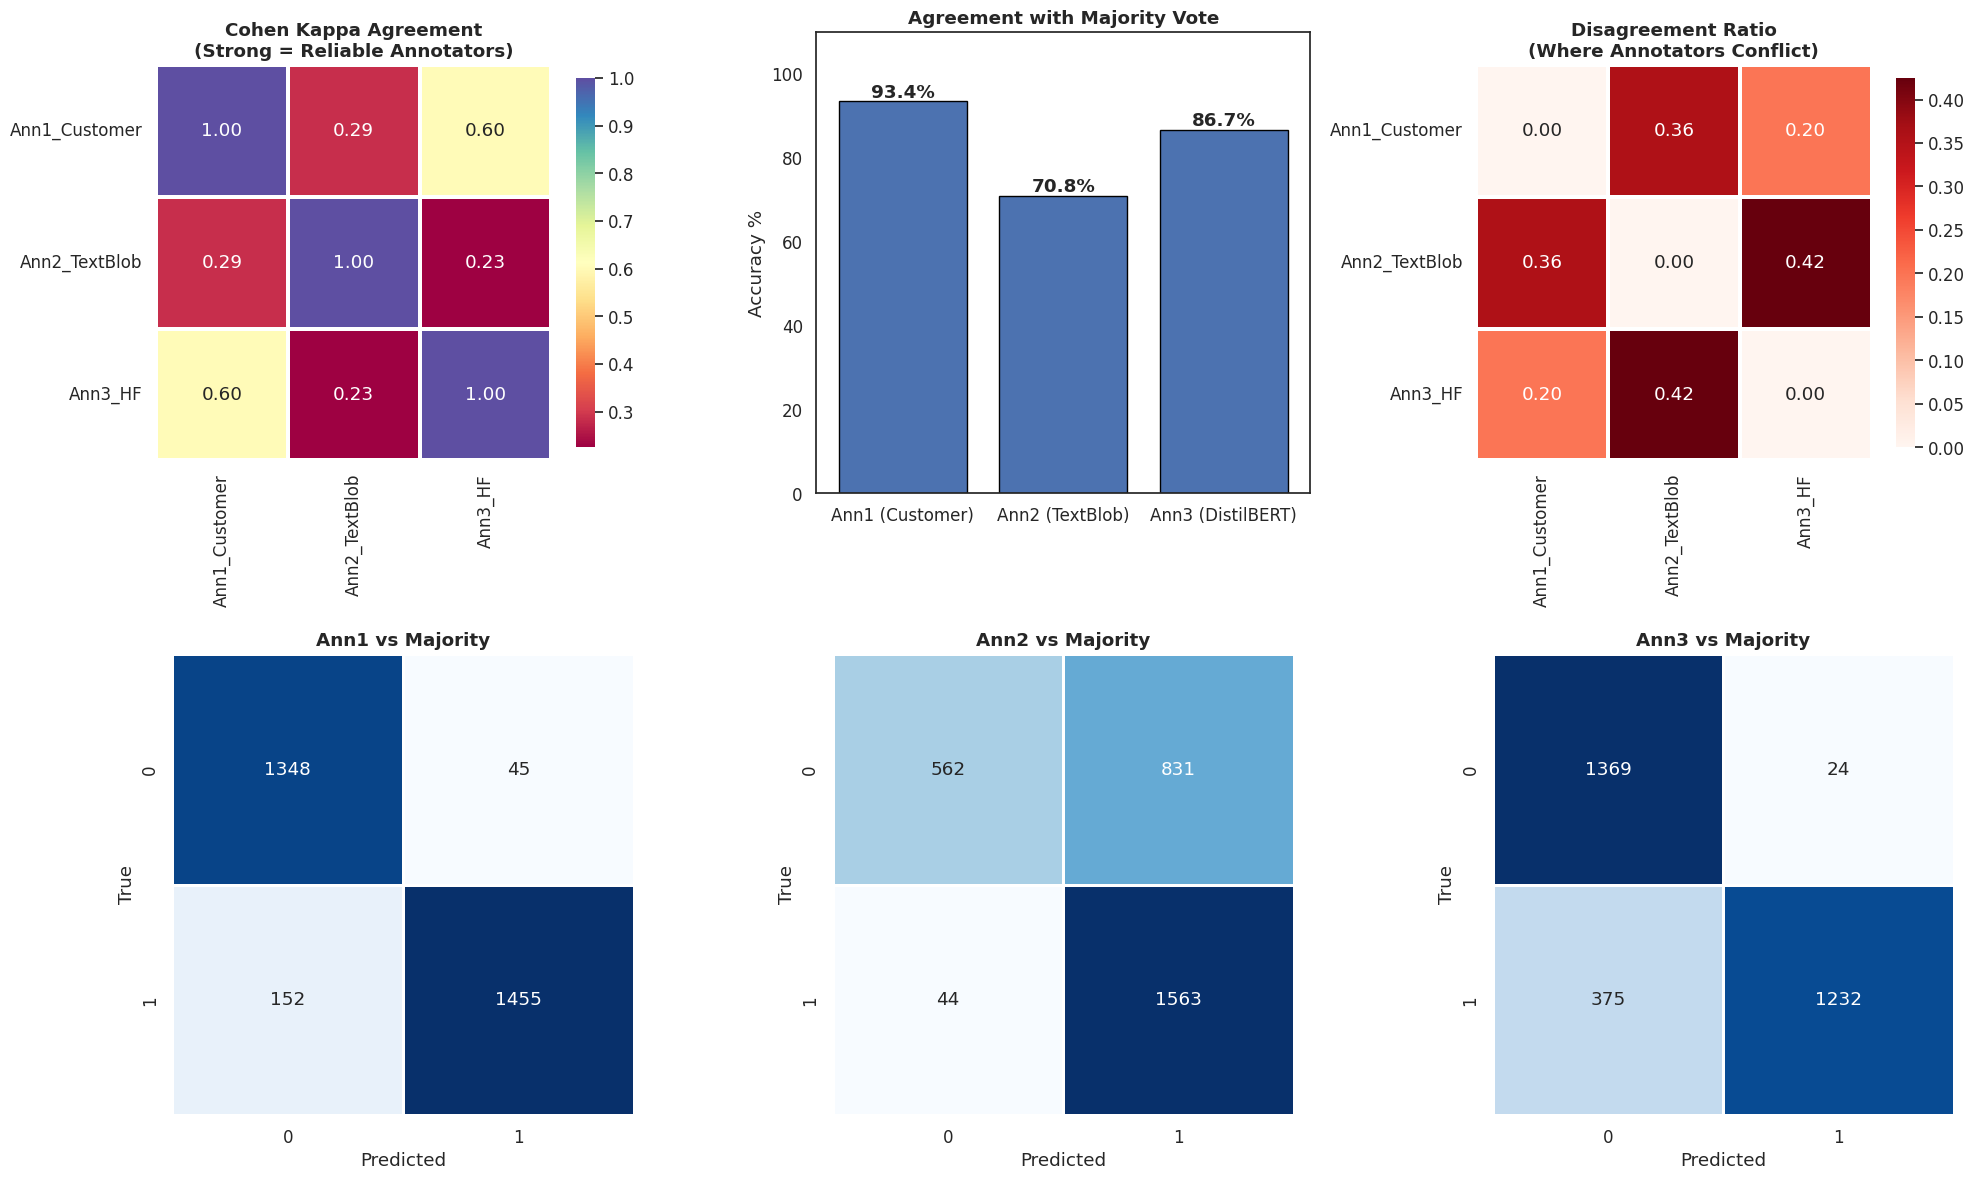

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix

# Better theme
sns.set_theme(style="white", font_scale=1.1)

annotators = ['Ann1_Customer', 'Ann2_TextBlob', 'Ann3_HF']

# =========================
# 1. Pairwise Cohen Kappa
# =========================
kappa_matrix = pd.DataFrame(index=annotators, columns=annotators)

for a1 in annotators:
    for a2 in annotators:
        kappa_matrix.loc[a1, a2] = cohen_kappa_score(final_svm_data[a1], final_svm_data[a2])

kappa_matrix = kappa_matrix.astype(float)

# =========================
# 2. Accuracy vs Majority
# =========================
accuracies = {
    'Ann1 (Customer)': accuracy_score(final_svm_data['Majority_Truth'], final_svm_data['Ann1_Customer']),
    'Ann2 (TextBlob)': accuracy_score(final_svm_data['Majority_Truth'], final_svm_data['Ann2_TextBlob']),
    'Ann3 (DistilBERT)': accuracy_score(final_svm_data['Majority_Truth'], final_svm_data['Ann3_HF'])
}

# =========================
# 3. Disagreement Matrix
# =========================
disagreement_matrix = pd.DataFrame(index=annotators, columns=annotators)

for a1 in annotators:
    for a2 in annotators:
        disagreement_matrix.loc[a1, a2] = (final_svm_data[a1] != final_svm_data[a2]).mean()

disagreement_matrix = disagreement_matrix.astype(float)

# =========================
# 4. Dashboard Layout
# =========================
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3)

# -------------------------
# A. Kappa Heatmap (Enhanced Colors)
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    kappa_matrix,
    annot=True,
    cmap='Spectral',
    fmt=".2f",
    linewidths=1.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax1
)
ax1.set_title('Cohen Kappa Agreement\n(Strong = Reliable Annotators)', fontweight='bold')

# -------------------------
# B. Accuracy Bar Chart
# -------------------------
ax2 = fig.add_subplot(gs[0, 1])
labels = list(accuracies.keys())
values = [v * 100 for v in accuracies.values()]

bars = ax2.bar(labels, values, edgecolor='black')

ax2.set_ylim(0, 110)
ax2.set_title('Agreement with Majority Vote', fontweight='bold')
ax2.set_ylabel('Accuracy %')

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2.,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        fontweight='bold'
    )

# -------------------------
# C. Disagreement Heatmap)
# -------------------------
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(
    disagreement_matrix,
    annot=True,
    cmap='Reds',
    fmt=".2f",
    linewidths=1.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax3
)

ax3.set_title('Disagreement Ratio\n(Where Annotators Conflict)', fontweight='bold')

# -------------------------
# D/E/F Confusion Matrices
# -------------------------
def plot_cm(ax, true, pred, title):
    cm = confusion_matrix(true, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=1,
        square=True,
        cbar=False,
        ax=ax
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

ax4 = fig.add_subplot(gs[1, 0])
plot_cm(ax4, final_svm_data['Majority_Truth'], final_svm_data['Ann1_Customer'], 'Ann1 vs Majority')

ax5 = fig.add_subplot(gs[1, 1])
plot_cm(ax5, final_svm_data['Majority_Truth'], final_svm_data['Ann2_TextBlob'], 'Ann2 vs Majority')

ax6 = fig.add_subplot(gs[1, 2])
plot_cm(ax6, final_svm_data['Majority_Truth'], final_svm_data['Ann3_HF'], 'Ann3 vs Majority')

plt.tight_layout()
plt.show()

# Phase 2 Text Representation

In [ ]:
import os

print("Downloading GloVe vectors directly from Stanford University...")
# 1. Download the zip file directly from the source
!wget -nc http://nlp.stanford.edu/data/glove.6B.zip

print("\nUnzipping the files...")
# 2. Unzip the file (-q means quiet, so it doesn't flood your screen with output)
!unzip -q -o glove.6B.zip

# 3. Verify the file your professor asked for is there
print("\nFiles ready!")
!ls -lh glove.6B.100d.txt

File ‘glove.6B.zip’ already there; not retrieving.


Unzipping the files...

Files ready!
-rw-rw-r-- 1 root root 332M Aug  4  2014 glove.6B.100d.txt


#**3 SCHEMA text preprocessing**


In [ ]:
import re
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob # For spell correction

# Initialize tools
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# --- SCHEME 1: Lemmatization + Spell Correction ---
def preprocess_scheme_1(text):
    text = str(text).lower()
    # Basic spell check (Note: this is slow on large datasets)
    # text = str(TextBlob(text).correct())
    words = re.findall(r'\b\w+\b', text)
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

# --- SCHEME 2: URL & Special Character Removal ---
def preprocess_scheme_2(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text) # Remove special chars and numbers
    return ' '.join(text.split())

# --- SCHEME 3: Stemming + Contraction Expansion ---
def preprocess_scheme_3(text):
    # Expansion (simple manual map)
    text = text.lower().replace("don't", "do not").replace("can't", "cannot").replace("it's", "it is")
    words = re.findall(r'\b\w+\b', text)
    return ' '.join([stemmer.stem(w) for w in words])

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

# Initialize tqdm for pandas to show progress bars
tqdm.pandas()

# Using a general name for the main dataframe
df_sentiment = final_svm_data.copy()

print("Executing 3 Preprocessing Schemes...")

# --- APPLY SCHEME 1: Lemmatization + Spell Correction ---
print("\nProcess 1: Applying Lemmatization & Correction...")
df_sentiment['Text_Lemmatized'] = df_sentiment['Text'].progress_apply(preprocess_scheme_1)

# --- APPLY SCHEME 2: URL & Special Character Removal ---
print("\nProcess 2: Cleaning URLs & Special Characters...")
df_sentiment['Text_Cleaned'] = df_sentiment['Text'].progress_apply(preprocess_scheme_2)

# --- APPLY SCHEME 3: Stemming + Contraction Expansion ---
print("\nProcess 3: Applying Stemming & Expansion...")
df_sentiment['Text_Stemmed'] = df_sentiment['Text'].progress_apply(preprocess_scheme_3)

print("\n" + "═"*60)
print("PREPROCESSING COMPLETE")
print("═"*60)

# Display comparison to verify differences
print("Visual Comparison of Processing Techniques:")
# Display the original text alongside the three new processed versions
display(df_sentiment[['Text', 'Text_Lemmatized', 'Text_Cleaned', 'Text_Stemmed']].head(5))



Executing 3 Preprocessing Schemes...

Process 1: Applying Lemmatization & Correction...


  0%|          | 0/3000 [00:00<?, ?it/s]


Process 2: Cleaning URLs & Special Characters...


  0%|          | 0/3000 [00:00<?, ?it/s]


Process 3: Applying Stemming & Expansion...


  0%|          | 0/3000 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
PREPROCESSING COMPLETE
════════════════════════════════════════════════════════════
Visual Comparison of Processing Techniques:


,Text,Text_Lemmatized,Text_Cleaned,Text_Stemmed
0,Annie Chun's Classic Pad Thai Meal Kit provide...,annie chun s classic pad thai meal kit provide...,annie chuns classic pad thai meal kit provides...,anni chun s classic pad thai meal kit provid t...
1,I really wish Amazon would list ingredients fo...,i really wish amazon would list ingredient for...,i really wish amazon would list ingredients fo...,i realli wish amazon would list ingredi for th...
2,"The blend is beautiful, flavorful and gives of...",the blend is beautiful flavorful and give of a...,the blend is beautiful flavorful and gives of ...,the blend is beauti flavor and give of an incr...
3,I have a great amount of experience with water...,i have a great amount of experience with water...,i have a great amount of experience with water...,i have a great amount of experi with water kef...
4,"Great flavor, fast easy to prepare...makes gre...",great flavor fast easy to prepare make great c...,great flavor fast easy to preparemakes great c...,great flavor fast easi to prepar make great ch...


# **The TF-IDF Representation**

In [ ]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

print("⚙️ Building TF-IDF Representation...")

# We limit to the top 3000 most important words so the matrix doesn't crash your RAM
tfidf = TfidfVectorizer(max_features=3000)

# Fit and transform the CLEAN text
X_tfidf = tfidf.fit_transform(df_sentiment['Text_Cleaned'])

# Save TF-IDF matrix and the Ground Truth labels together using Pickle
with open('TFIDF_features.pkl', 'wb') as f:
    pickle.dump({'features': X_tfidf, 'labels': final_svm_data['Majority_Truth'].values}, f)

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")
print("Saved successfully as 'TFIDF_features.pkl'")

⚙️ Building TF-IDF Representation...
TF-IDF Matrix Shape: (3000, 3000)
Saved successfully as 'TFIDF_features.pkl'


#**The GloVe Representation**

In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Initialize the loading bar
tqdm.pandas(desc="GloVe Conversion Progress")

print("Loading Stanford GloVe Dictionary")
glove_dict = {}

# Read the massive text file we downloaded
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        # Convert the 100 coordinates into a numpy array
        vector = np.asarray(values[1:], dtype='float32')
        glove_dict[word] = vector

print(f"Loaded {len(glove_dict)} words into memory!")

# Function to convert a whole review into a single 100-dimension vector
def get_glove_vector(text):
    words = str(text).split()
    # Get the GloVe vector for every word in the review (if it exists in the dictionary)
    vectors = [glove_dict[w] for w in words if w in glove_dict]

    # Average them together (Mean Pooling)
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        # If empty, return a grid of 100 zeros
        return np.zeros(100)

print("\n🚀 Converting Reviews to GloVe Vectors...")
glove_features = df_sentiment['Text_Cleaned'].progress_apply(get_glove_vector)

# Convert the pandas list into a clean 2D mathematical matrix
X_glove = np.vstack(glove_features.values)

# Save GloVe as a CSV to satisfy the rubric
glove_df = pd.DataFrame(X_glove)
glove_df['Target_Label'] = df_sentiment['Majority_Truth'].values # Attach Ground Truth
glove_df.to_csv('GloVe_features.csv', index=False)

print(f"\nGloVe Matrix Shape: {X_glove.shape}")
print("Saved successfully as 'GloVe_features.csv'")

Loading Stanford GloVe Dictionary
Loaded 400000 words into memory!

🚀 Converting Reviews to GloVe Vectors...


GloVe Conversion Progress:   0%|          | 0/3000 [00:00<?, ?it/s]


GloVe Matrix Shape: (3000, 100)
Saved successfully as 'GloVe_features.csv'


#**Phase 3 part 1 (Lemmatization & Correction) Modelling** **Lexical-Based Modelling**


#**The VADER Model**

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# Initialize loading bar
tqdm.pandas(desc="VADER Scoring Progress")

print("Downloading VADER Lexicon...")
nltk.download('vader_lexicon', quiet=True)

# 1. Initialize the Model
vader_analyzer = SentimentIntensityAnalyzer()

# 2. Define the scoring logic
def get_vader_prediction(text):
    # VADER returns a dictionary of scores. We want the 'compound' score (-1 to 1)
    score_dict = vader_analyzer.polarity_scores(str(text))
    compound_score = score_dict['compound']

    # If the score is greater than 0, it's Positive (1). Otherwise, Negative (0).
    return 1 if compound_score > 0 else 0

print("Running VADER Classifier on Raw Text_Lemmatized...")
# Apply the model to the original, untouched Text column
df_sentiment['VADER_Pred'] = df_sentiment['Text_Lemmatized'].progress_apply(get_vader_prediction)

# 3. Grade the Model (Compare predictions to Ground Truth)
vader_acc = accuracy_score(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'])

print("\n" + "="*60)
print("VADER MODEL REPORT CARD")
print("="*60)
print(f"Overall Accuracy: {vader_acc * 100:.2f}%\n")
print("Detailed Breakdown:")
print(classification_report(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'], target_names=['Negative (0)', 'Positive (1)']))

Running VADER Classifier on Raw Text_Lemmatized...


VADER Scoring Progress:   0%|          | 0/3000 [00:00<?, ?it/s]


VADER MODEL REPORT CARD
Overall Accuracy: 69.03%

Detailed Breakdown:
              precision    recall  f1-score   support

Negative (0)       0.89      0.38      0.53      1393
Positive (1)       0.64      0.96      0.77      1607

    accuracy                           0.69      3000
   macro avg       0.76      0.67      0.65      3000
weighted avg       0.76      0.69      0.66      3000



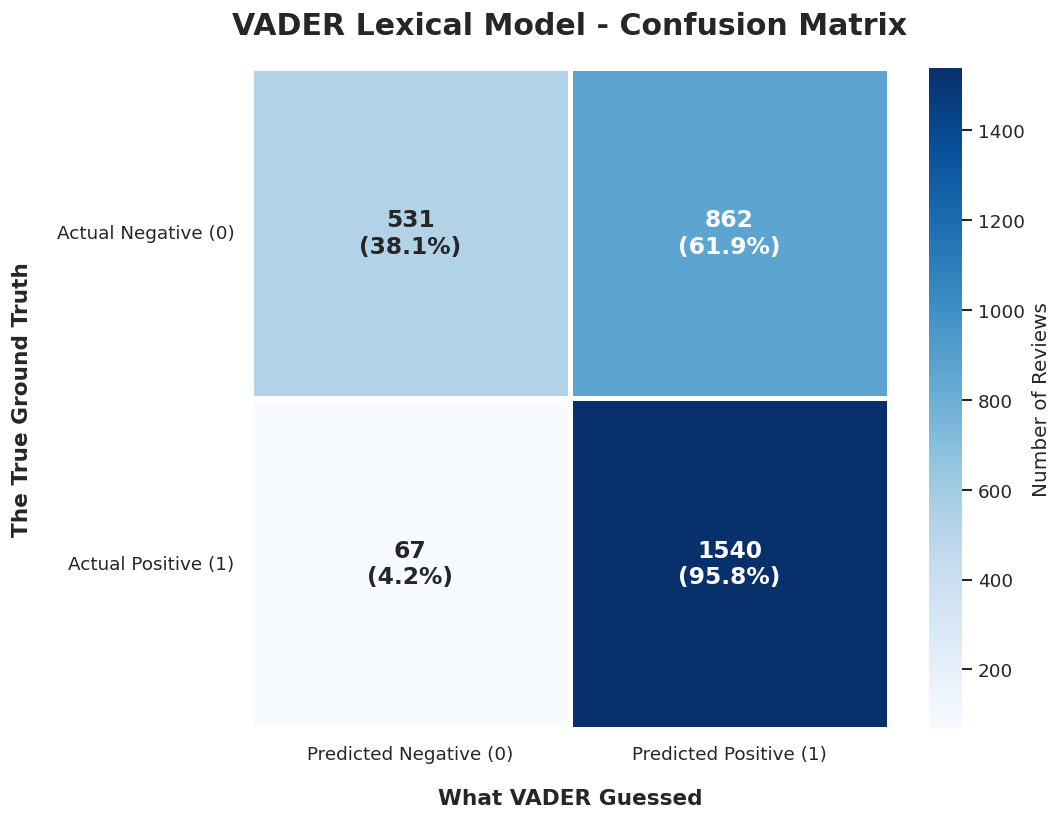

In [ ]:
# 1. Calculate the Confusion Matrix
cm_vader = confusion_matrix(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'])

# 2. ENHANCEMENT: Calculate percentages for richer data
# This allows us to see the recall/accuracy per class at a glance
cm_percentages = cm_vader.astype('float') / cm_vader.sum(axis=1)[:, np.newaxis]
annotations = [f"{count}\n({pct:.1%})" for count, pct in zip(cm_vader.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (dpi=120 for sharpness)
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Clean background to make the blue pop

# 4. Create the Enhanced Heatmap
# Using 'Blues' cmap and white thick linewidths for a modern UI look
ax = sns.heatmap(cm_vader,
                 annot=annotations,
                 fmt='',
                 cmap='Blues',
                 linewidths=3,
                 linecolor='white',
                 annot_kws={"size": 14, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Labeling
plt.title('VADER Lexical Model - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What VADER Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style adjustment for ticks
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Custom AFINN Model (From Scratch)**

In [ ]:
import urllib.request
import re
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

tqdm.pandas(desc="AFINN Scoring Progress")

# 1. Download the raw AFINN dictionary from scratch
print("Downloading raw AFINN dictionary...")
url = "https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt"
response = urllib.request.urlopen(url)
raw_afinn_data = response.read().decode('utf-8').split('\n')

# 2. Build the dictionary from scratch
afinn_dict = {}
for line in raw_afinn_data:
    if '\t' in line:
        word, score = line.split('\t')
        afinn_dict[word.strip()] = int(score.strip())
print(f"Loaded {len(afinn_dict)} words into our Custom AFINN Dictionary.")

# 3. Define Negation Words
negation_words = {'not', 'no', 'never', 'none', 'neither', 'cannot', "isn't", "wasn't", "aren't", "doesn't", "don't", "won't", "wouldn't", "couldn't", "shouldn't", "can't"}

# 4. Create the Custom Scoring Function WITH NEGATION logic
def custom_afinn_scorer(text):
    # Lowercase the text and split it into clean words using regex
    words = re.findall(r'\b\w+\b', str(text).lower())

    total_score = 0

    # Loop through words using an index so we can look backward
    for i in range(len(words)):
        word = words[i]

        # Check if the word is in our AFINN dictionary
        if word in afinn_dict:
            word_score = afinn_dict[word]

            # NEGATION RULE: Check if the word BEFORE it was a negation word
            if i > 0 and words[i-1] in negation_words:
                word_score = word_score * -1  # Flip the score! (e.g., "not good" -> 3 becomes -3)

            total_score += word_score

    # Final prediction: Positive if total > 0, else Negative
    return 1 if total_score > 0 else 0

print("\nRunning Custom AFINN Classifier on Raw Text_Lemmatized...")
df_sentiment['AFINN_Pred'] = df_sentiment['Text_Lemmatized'].progress_apply(custom_afinn_scorer)
# 5. Grade the Model
afinn_acc = accuracy_score(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'])

print("\n" + "="*60)
print("CUSTOM AFINN MODEL REPORT CARD")
print("="*60)
print(f"Overall Accuracy: {afinn_acc * 100:.2f}%\n")
print(classification_report(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'], target_names=['Negative (0)', 'Positive (1)']))



Loaded 2477 words into our Custom AFINN Dictionary.

Running Custom AFINN Classifier on Raw Text_Lemmatized...


AFINN Scoring Progress:   0%|          | 0/3000 [00:00<?, ?it/s]


CUSTOM AFINN MODEL REPORT CARD
Overall Accuracy: 69.10%

              precision    recall  f1-score   support

Negative (0)       0.85      0.40      0.55      1393
Positive (1)       0.65      0.94      0.77      1607

    accuracy                           0.69      3000
   macro avg       0.75      0.67      0.66      3000
weighted avg       0.74      0.69      0.66      3000



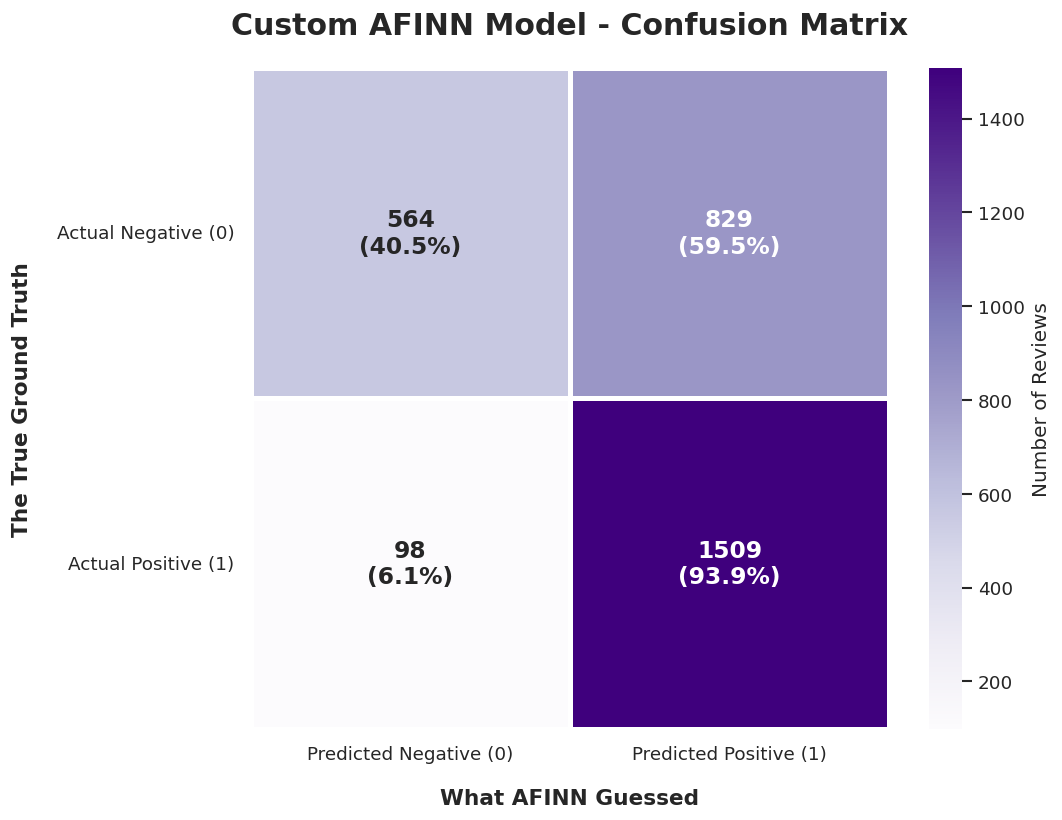

In [ ]:
# 1. Generate the matrix
cm_afinn = confusion_matrix(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'])

# 2. ENHANCEMENT: Calculate percentages for the annotations
# This creates labels like "150\n(85.5%)" instead of just "150"
cm_percentages = cm_afinn.astype('float') / cm_afinn.sum(axis=1)[:, np.newaxis]
annotations = [f"{count}\n({pct:.1%})" for count, pct in zip(cm_afinn.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (added dpi=120 for a much sharper, high-res image)
plt.figure(figsize=(9, 7), dpi=120)

# Removed the grid background because heatmaps look cleaner without it
sns.set_theme(style="white")

# 4. The Heatmap (Using 'Purples' colormap)
# Changed linecolor to white and made them thicker for a modern "tile" look
ax = sns.heatmap(cm_afinn,
                 annot=annotations,
                 fmt='', # Set to empty string since our annotations are custom strings now
                 cmap='Purples',
                 linewidths=3,
                 linecolor='white',
                 annot_kws={"size": 14, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Enhanced Typography and Spacing
# Added 'pad' and 'labelpad' to push the titles away from the graph slightly so it doesn't look cramped
plt.title('Custom AFINN Model - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What AFINN Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Ensure tick labels are readable and y-labels stay perfectly horizontal
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

# Ensures nothing gets cut off at the edges of the image
plt.tight_layout()
plt.show()

# **Phase 3 Machine Learning-Based Modelling**

# **1 SVM Experiment  (TF-IDF)**

In [ ]:
import pickle
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Feature Generation (Specific to Process 1: Lemmatization)
print("Generating TF-IDF Features for Lemmatized Process...")
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

# We use the new general dataframe and the specific Lemmatized column
X = tfidf_vectorizer.fit_transform(df_sentiment['Text_Lemmatized'])
y = df_sentiment['Majority_Truth'].values

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split: Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

# 3. Initialize and Train the SVM
print("\nTraining SVM Model...")
svm_tfidf = SVC(kernel='linear', C=1.0)

with tqdm(total=1, desc="SVM Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    svm_tfidf.fit(X_train, y_train)
    pbar.update(1)

# 4. Make Predictions
print("\nGenerating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    y_pred = svm_tfidf.predict(X_test)
    pbar.update(1)

print("\nProcess Complete")

# --- Results Text Output ---
tfidf_acc = accuracy_score(y_test, y_pred)
print("\n" + "═"*60)
print(f"SVM EXPERIMENT: TF-IDF")
print("═"*60)
print(f"Final Accuracy: {tfidf_acc * 100:.2f}%")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═" * 60 + "\n")

Generating TF-IDF Features for Lemmatized Process...
Data Split: Training: 2400 | Testing: 600

Training SVM Model...


SVM Fitting:   0%|          | 00:00


Generating Predictions...


Predicting:   0%|          | 00:00


Process Complete

════════════════════════════════════════════════════════════
SVM EXPERIMENT: TF-IDF
════════════════════════════════════════════════════════════
Final Accuracy: 81.67%

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.8140    0.8194    0.8167       299
Positive (1)     0.8194    0.8140    0.8167       301

    accuracy                         0.8167       600
   macro avg     0.8167    0.8167    0.8167       600
weighted avg     0.8167    0.8167    0.8167       600

════════════════════════════════════════════════════════════



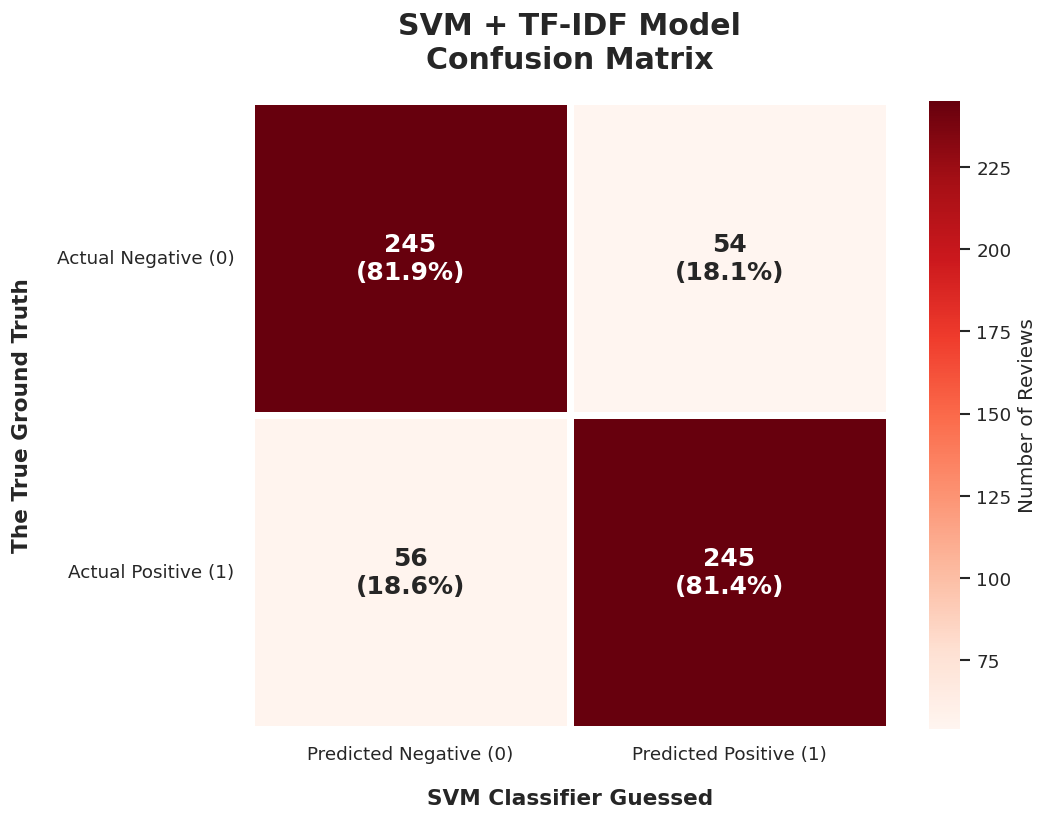

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate the raw Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. ENHANCEMENT: Generate annotations with Counts + Percentages
# (axis=1 calculates percentages relative to the ACTUAL class)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup for high-quality output
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Remove gridlines from the background

# 4. Create the Heatmap (Using 'Reds' and thick white borders)
ax = sns.heatmap(cm,
                 annot=annotations,
                 fmt='', # Use empty string for our custom annotations
                 cmap='Reds', # Apply the requested Red theme
                 linewidths=4, # Thicker lines look very modern
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Labeling and Typography
plt.title('SVM + TF-IDF Model\nConfusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('SVM Classifier Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style tick labels for readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0) # Keep Y-axis labels horizontal

plt.tight_layout()
plt.show()

# **2 SVM Experiment (GloVe Vectors)**

In [ ]:
import numpy as np
from tqdm.auto import tqdm

# 1. Define the path to your GloVe file
# Change this if your filename is different (e.g., 'glove.6B.50d.txt')
glove_path = 'glove.6B.100d.txt'

embeddings_dict = {}

print(f"Loading GloVe Embeddings from {glove_path}...")

# 2. Open the file and read word by word
try:
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=400000, desc="Loading GloVe"):
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_dict[word] = vector
    print(f"Success! Loaded {len(embeddings_dict)} word vectors.")
except FileNotFoundError:
    print(f"Error: {glove_path} not found. Please upload the GloVe file to your directory.")


Loading GloVe Embeddings from glove.6B.100d.txt...


Loading GloVe:   0%|          | 0/400000 [00:00<?, ?it/s]

Success! Loaded 400000 word vectors.


In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Feature Generation Function (Internal)
def get_glove_vector(text, model, vector_size=100):
    words = str(text).split()
    # Pull vectors for words that exist in the pre-loaded GloVe embeddings
    vectors = [model[word] for word in words if word in model]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# 2. Vectorize the 'Text_Lemmatized' Column
print("Step 1: Transforming 'Text_Lemmatized' into GloVe Vectors...")
X_list = []
for text in tqdm(df_sentiment['Text_Lemmatized'], desc="Vectorizing"):
    X_list.append(get_glove_vector(text, embeddings_dict))

X = np.array(X_list)
y = df_sentiment['Majority_Truth'].values

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split Complete: {X_train.shape[0]} training samples.")

# 4. Initialize and Train SVM (RBF Kernel)
print("\nStep 2: Training SVM (RBF Kernel) on GloVe Features...")
svm_glove = SVC(kernel='rbf', C=1.0)

with tqdm(total=1, desc="SVM Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    svm_glove.fit(X_train, y_train)
    pbar.update(1)

# 5. Make Predictions & Report Results
print("\nStep 3: Generating Results...")
y_pred = svm_glove.predict(X_test)
glove_acc = accuracy_score(y_test, y_pred)

print("\n" + "═"*60)
print("SVM EXPERIMENT: GLOVE + LEMMATIZATION")
print("═"*60)
print(f"Accuracy Score: {glove_acc * 100:.2f}%")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Step 1: Transforming 'Text_Lemmatized' into GloVe Vectors...


Vectorizing:   0%|          | 0/3000 [00:00<?, ?it/s]

Data Split Complete: 2400 training samples.

Step 2: Training SVM (RBF Kernel) on GloVe Features...


SVM Fitting:   0%|          | 00:00


Step 3: Generating Results...

════════════════════════════════════════════════════════════
SVM EXPERIMENT: GLOVE + LEMMATIZATION
════════════════════════════════════════════════════════════
Accuracy Score: 73.33%

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7747    0.6555    0.7101       299
Positive (1)     0.7032    0.8106    0.7531       301

    accuracy                         0.7333       600
   macro avg     0.7389    0.7331    0.7316       600
weighted avg     0.7388    0.7333    0.7317       600

════════════════════════════════════════════════════════════


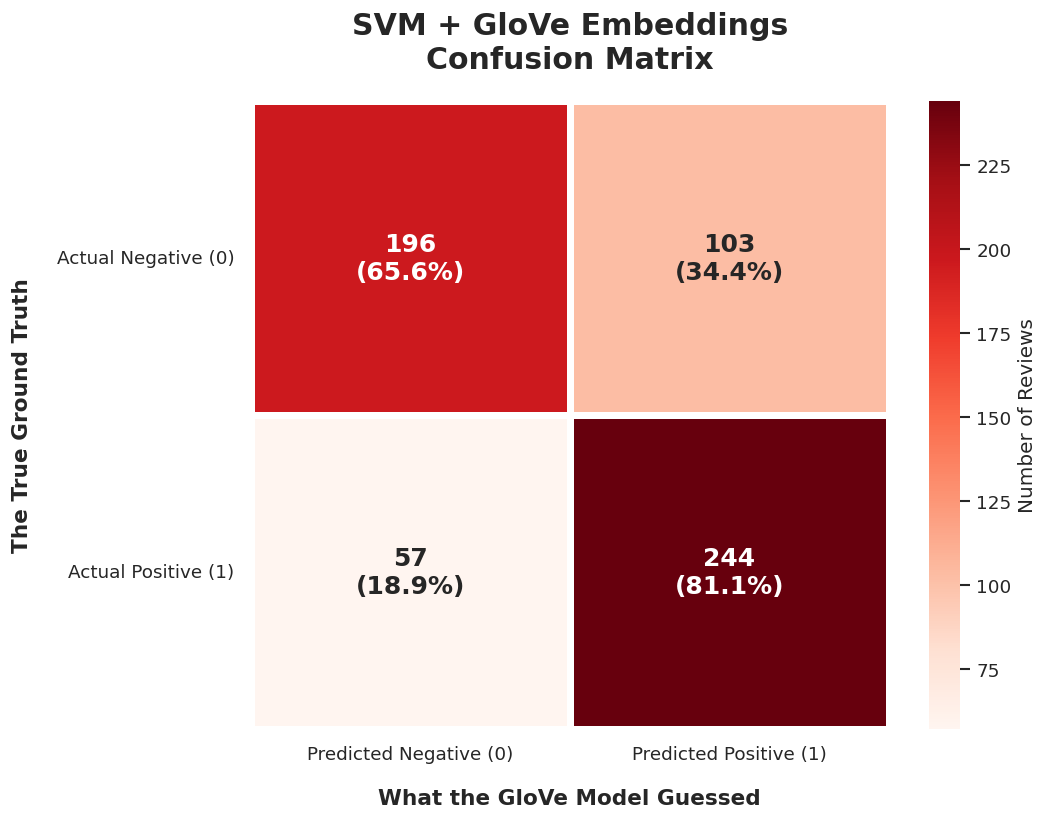

In [ ]:
cm_glove = confusion_matrix(y_test, y_pred)

# 2. ENHANCEMENT: Generate dual annotations (Count + Percentage)
# Percentages help show where the model is biased toward a specific class
cm_percentages = cm_glove.astype('float') / cm_glove.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_glove.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (High-Resolution)
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Clean background

# 4. Create the Enhanced Red Heatmap
# Using thicker white linewidths for a modern "dashboard" look
ax = sns.heatmap(cm_glove,
                 annot=annotations,
                 fmt='',
                 cmap='Reds',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Typography
plt.title('SVM + GloVe Embeddings\nConfusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What the GloVe Model Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style tick labels
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Linear Regression Model +TF-IDF**


In [ ]:
import numpy as np
from tqdm.auto import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# 1. Feature Generation (Reading directly from the Lemmatized column)
print("Generating TF-IDF Features from 'Text_Lemmatized'...")
# We use the same parameters as the SVM to keep the comparison fair
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

with tqdm(total=1, desc="Vectorizing Text") as pbar:
    # Use the general dataframe name you defined
    X = tfidf_vectorizer.fit_transform(df_sentiment['Text_Lemmatized'])
    y = df_sentiment['Majority_Truth'].values
    pbar.update(1)

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split: Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

# 3. Train Linear Regression
print(f"\nTraining Linear Regression Model...")
lin_reg = LinearRegression()

with tqdm(total=1, desc="Regression Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Linear Regression treats y as continuous values (0.0 to 1.0)
    lin_reg.fit(X_train, y_train)
    pbar.update(1)

# 4. Predict & Threshold
print("\nGenerating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Get raw decimal scores (e.g. 0.85, 0.12)
    raw_predictions = lin_reg.predict(X_test)

    # Convert to Binary Labels: >= 0.5 is Positive (1), else Negative (0)
    y_pred_binary = (raw_predictions >= 0.5).astype(int)
    pbar.update(1)

# 5. Results Output
reg_acc = accuracy_score(y_test, y_pred_binary)
mse = mean_squared_error(y_test, raw_predictions)

print("\n" + "═"*60)
print("FINAL MODEL: LINEAR REGRESSION + TF-IDF (LEMMATIZATION)")
print("═"*60)
print(f"Accuracy Score (Thresholded): {reg_acc * 100:.2f}%")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred_binary, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Generating TF-IDF Features from 'Text_Lemmatized'...


Vectorizing Text:   0%|          | 0/1 [00:00<?, ?it/s]

Data Split: Training: 2400 | Testing: 600

Training Linear Regression Model...


Regression Fitting:   0%|          | 00:00


Generating Predictions...


Predicting:   0%|          | 00:00


════════════════════════════════════════════════════════════
FINAL MODEL: LINEAR REGRESSION + TF-IDF (LEMMATIZATION)
════════════════════════════════════════════════════════════
Accuracy Score (Thresholded): 62.50%
Mean Squared Error (MSE):     0.7141

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.6201    0.6388    0.6293       299
Positive (1)     0.6301    0.6113    0.6206       301

    accuracy                         0.6250       600
   macro avg     0.6251    0.6250    0.6249       600
weighted avg     0.6252    0.6250    0.6249       600

════════════════════════════════════════════════════════════


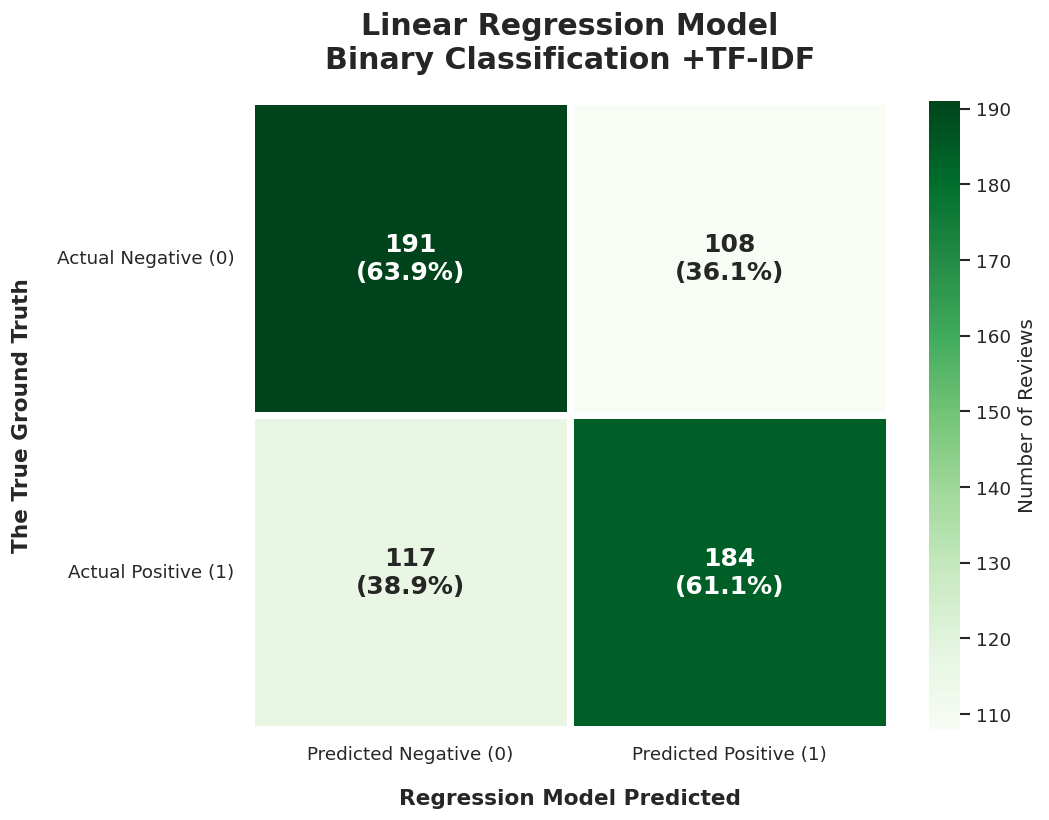

In [ ]:
# 1. Calculate Matrix
cm_reg = confusion_matrix(y_test, y_pred_binary)

# 2. Calculate Percentages
cm_percentages = cm_reg.astype('float') / cm_reg.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_reg.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white")

# 4. Heatmap (Using 'Greens' and white borders)
ax = sns.heatmap(cm_reg,
                 annot=annotations,
                 fmt='',
                 cmap='Greens',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Labels & Title
plt.title('Linear Regression Model\nBinary Classification +TF-IDF', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Regression Model Predicted', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Linear Regression Model +GLOVE**


In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# 1. Feature Generation Function (Internal)
def get_glove_vector(text, model, vector_size=100):
    words = str(text).split()
    # Pull vectors for words that exist in your pre-loaded glove_dict
    vectors = [model[word] for word in words if word in model]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# 2. Vectorize the 'Text_Lemmatized' Column
print("Step 1: Transforming 'Text_Lemmatized' into GloVe Vectors...")
X_list = []
# Using your general dataframe name: df_sentiment
for text in tqdm(df_sentiment['Text_Lemmatized'], desc="Vectorizing"):
    X_list.append(get_glove_vector(text, glove_dict)) # Using glove_dict as defined in your loading cell

X = np.array(X_list)
y = df_sentiment['Majority_Truth'].values

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split Complete: {X_train.shape[0]} training samples.")

# 4. Train Linear Regression
print(f"\nStep 2: Training Linear Regression on GloVe vectors...")
lin_reg = LinearRegression()

with tqdm(total=1, desc="Regression Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    lin_reg.fit(X_train, y_train)
    pbar.update(1)

# 5. Predict & Threshold
print("Step 3: Generating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Linear Regression outputs continuous numbers
    raw_predictions = lin_reg.predict(X_test)

    # Thresholding: If the predicted value is >= 0.5, classify as Positive (1)
    y_pred_binary = (raw_predictions >= 0.5).astype(int)
    pbar.update(1)

# 6. Calculate & Display Metrics
reg_acc_glove = accuracy_score(y_test, y_pred_binary)
mse = mean_squared_error(y_test, raw_predictions)

print("\n" + "═"*60)
print("FINAL MODEL: LINEAR REGRESSION (GLOVE + LEMMATIZATION)")
print("═"*60)
print(f"Accuracy Score (Thresholded): {reg_acc_glove * 100:.2f}%")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred_binary, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Step 1: Transforming 'Text_Lemmatized' into GloVe Vectors...


Vectorizing:   0%|          | 0/3000 [00:00<?, ?it/s]

Data Split Complete: 2400 training samples.

Step 2: Training Linear Regression on GloVe vectors...


Regression Fitting:   0%|          | 00:00

Step 3: Generating Predictions...


Predicting:   0%|          | 00:00


════════════════════════════════════════════════════════════
FINAL MODEL: LINEAR REGRESSION (GLOVE + LEMMATIZATION)
════════════════════════════════════════════════════════════
Accuracy Score (Thresholded): 76.67%
Mean Squared Error (MSE):     0.1640

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7912    0.7224    0.7552       299
Positive (1)     0.7462    0.8106    0.7771       301

    accuracy                         0.7667       600
   macro avg     0.7687    0.7665    0.7662       600
weighted avg     0.7686    0.7667    0.7662       600

════════════════════════════════════════════════════════════


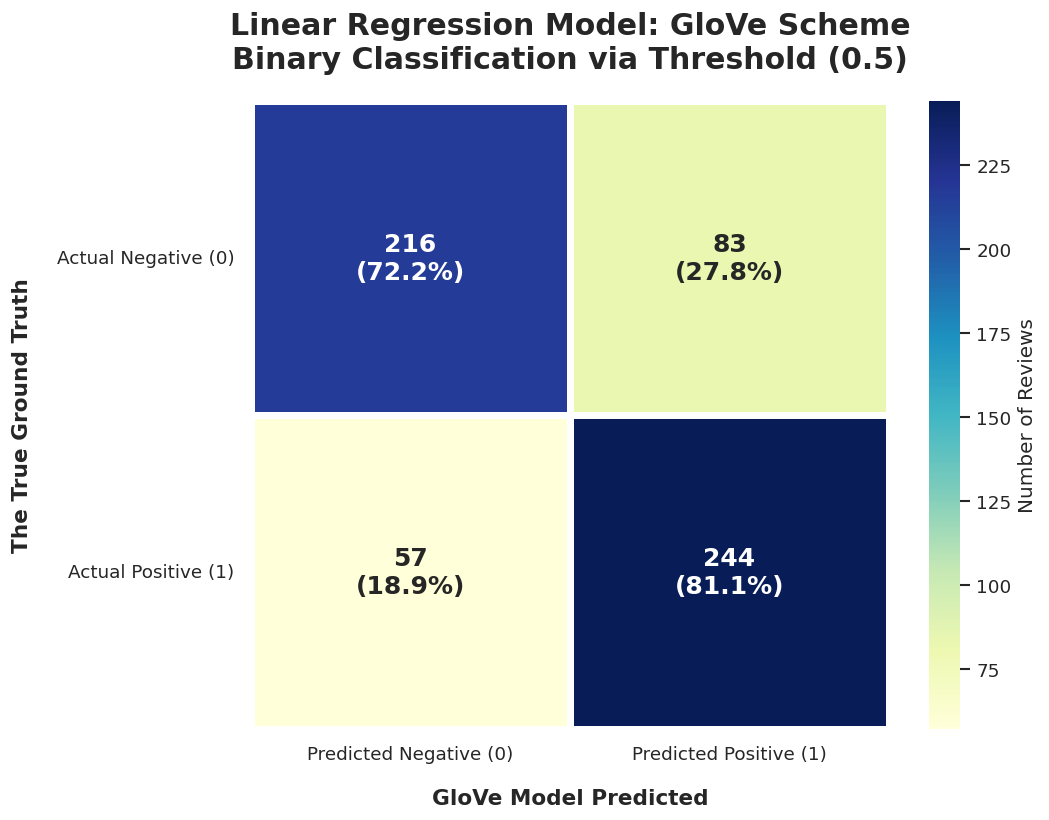

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate Matrix
# Assuming y_test and y_pred_binary are from your GloVe Regression run
cm_glove_reg = confusion_matrix(y_test, y_pred_binary)

# 2. Calculate Percentages for the annotations
cm_percentages = cm_glove_reg.astype('float') / cm_glove_reg.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_glove_reg.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white")

# 4. Heatmap (Using 'YlGnBu' to differentiate from the TF-IDF 'Greens')
ax = sns.heatmap(cm_glove_reg,
                 annot=annotations,
                 fmt='',
                 cmap='YlGnBu',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Labels & Title specifically for GloVe
plt.title('Linear Regression Model: GloVe Scheme\nBinary Classification via Threshold (0.5)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('GloVe Model Predicted', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# **final report (lemmatization)**

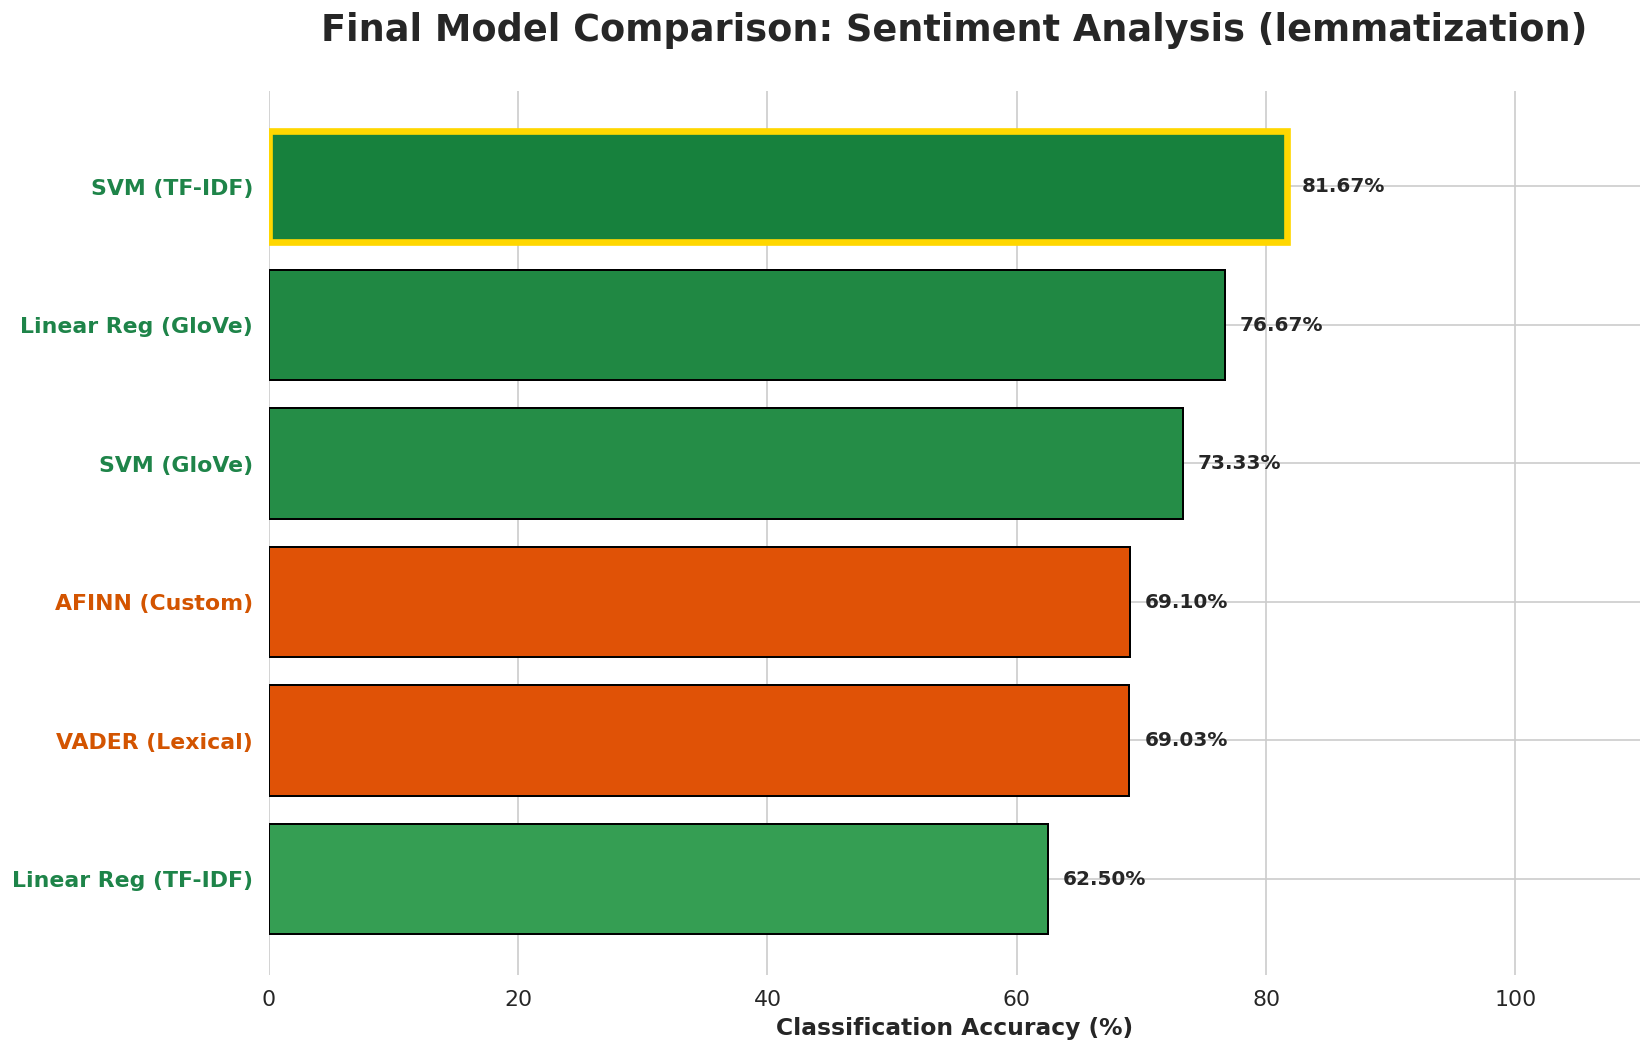


════════════════════════════════════════════════════════════
🏁 FINAL PROJECT RANKING
════════════════════════════════════════════════════════════
  Model Category          Model Name  Accuracy %
Machine Learning        SVM (TF-IDF)       81.67
Machine Learning  Linear Reg (GloVe)       76.67
Machine Learning         SVM (GloVe)       73.33
         Lexical      AFINN (Custom)       69.10
         Lexical     VADER (Lexical)       69.03
Machine Learning Linear Reg (TF-IDF)       62.50
------------------------------------------------------------
THE best model: SVM (TF-IDF) (81.67%)
════════════════════════════════════════════════════════════


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare data with the 6 specific models from your code
# Note: Ensure you have run all previous cells so these variables exist
performance_df = pd.DataFrame({
    'Model Category': [
        'Lexical', 'Lexical',
        'Machine Learning', 'Machine Learning',
        'Machine Learning', 'Machine Learning'
    ],
    'Model Name': [
        'VADER (Lexical)',
        'AFINN (Custom)',
        'SVM (TF-IDF)',
        'SVM (GloVe)',
        'Linear Reg (TF-IDF)',
        'Linear Reg (GloVe)'
    ],
    'Accuracy': [
        vader_acc,     # From VADER cell
        afinn_acc,     # From AFINN cell
        tfidf_acc,     # From SVM TF-IDF cell
        glove_acc,     # From SVM GloVe cell
        reg_acc,       # From Linear Regression TF-IDF cell
        reg_acc_glove  # Re-named to distinguish GloVe Reg from TF-IDF Reg
    ]
})

# 2. Convert to percentages and sort
performance_df['Accuracy %'] = (performance_df['Accuracy'] * 100).round(2)
performance_df = performance_df.sort_values(by='Accuracy %', ascending=True).reset_index(drop=True)

# 3. Styling and Colors
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, ax = plt.subplots(figsize=(14, 9), dpi=120)

colors = []
for _, row in performance_df.iterrows():
    if row['Model Category'] == 'Machine Learning':
        # Gradient Green for ML models
        colors.append(plt.cm.Greens(0.3 + (row['Accuracy'] * 0.6)))
    else:
        # Gradient Orange/Red for Lexical models
        colors.append(plt.cm.Oranges(0.3 + (row['Accuracy'] * 0.6)))

# 4. Create Horizontal Bar Chart
bars = ax.barh(
    performance_df['Model Name'],
    performance_df['Accuracy %'],
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

# 5. Highlight the Best Model with a Gold Border
best_idx = performance_df['Accuracy %'].idxmax()
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)

# 6. Add Accuracy Labels at the end of each bar
for i, value in enumerate(performance_df['Accuracy %']):
    ax.text(
        value + 1.2,
        i,
        f'{value:.2f}%',
        va='center',
        fontweight='bold',
        fontsize=12
    )

# 7. Labels and Titles
ax.set_title('Final Model Comparison: Sentiment Analysis (lemmatization)', fontsize=22, fontweight='bold', pad=30)
ax.set_xlabel('Classification Accuracy (%)', fontweight='bold', fontsize=14)
ax.set_xlim(0, 110) # Leave room for labels

# Color the Y-axis labels by category
for i, cat in enumerate(performance_df['Model Category']):
    if cat == 'Lexical':
        ax.get_yticklabels()[i].set_color('#d35400') # Deep Orange
        ax.get_yticklabels()[i].set_weight('bold')
    else:
        ax.get_yticklabels()[i].set_color('#1e8449') # Deep Green
        ax.get_yticklabels()[i].set_weight('bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 8. Final Insight Output
best_model_name = performance_df.iloc[-1]['Model Name']
best_model_acc = performance_df.iloc[-1]['Accuracy %']

print("\n" + "═"*60)
print("🏁 FINAL PROJECT RANKING")
print("═"*60)
print(performance_df[['Model Category', 'Model Name', 'Accuracy %']].sort_values(by='Accuracy %', ascending=False).to_string(index=False))
print("-" * 60)
print(f"THE best model: {best_model_name} ({best_model_acc}%)")
print("═"*60)

# Model Evaluation & Benchmarking


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Initialize an empty list to store all our model report cards
benchmark_results = []

# 2. Define the Master Evaluation Function
def evaluate_and_log(model_name, scheme, y_true, y_pred, y_prob=None):
    """Calculates all rubric metrics and appends to the master benchmark list."""

    # Calculate macro-averaged metrics to ensure balanced evaluation
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro')

    # Calculate ROC-AUC if probabilities or continuous scores are provided
    if y_prob is not None:
        roc = roc_auc_score(y_true, y_prob)
    else:
        roc = np.nan # Some models (like basic Lexical) might not have clean probabilities

    # Log the results
    benchmark_results.append({
        'Preprocessing Scheme': scheme,
        'Model Name': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc
    })

    print(f"✅ Logged metrics for: {model_name} ({scheme})")

print("Ready to evaluate 18 models...")

# 3. Generate the Final Leaderboard (Run this AFTER evaluating all models)
def display_final_benchmark():
    df_bench = pd.DataFrame(benchmark_results)

    # Sort by F1-Score (per rubric preference for F1 optimization)
    df_bench = df_bench.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

    # Format the table for the report
    styled_table = df_bench.style.format({
        'Accuracy': '{:.2%}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-Score': '{:.4f}',
        'ROC-AUC': '{:.4f}'
    }).background_gradient(subset=['F1-Score', 'ROC-AUC'], cmap='Greens')

    print("\n" + "═"*80)
    print("FULL 18-MODEL BENCHMARK & EVALUATION")
    print("═"*80)
    return styled_table

Ready to evaluate 18 models...


In [ ]:
# 1. Paste at bottom of VADER (Lemmatization) cell
evaluate_and_log('VADER', 'Lemmatization', df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'])

# 2. Paste at bottom of AFINN (Lemmatization) cell
evaluate_and_log('AFINN', 'Lemmatization', df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'])

# 3. Paste at bottom of SVM + TF-IDF (Lemmatization) cell
evaluate_and_log('SVM (TF-IDF)', 'Lemmatization', y_test, y_pred)

# 4. Paste at bottom of SVM + GloVe (Lemmatization) cell
evaluate_and_log('SVM (GloVe)', 'Lemmatization', y_test, y_pred)

# 5. Paste at bottom of Linear Regression + TF-IDF (Lemmatization) cell
evaluate_and_log('Linear Reg (TF-IDF)', 'Lemmatization', y_test, y_pred_binary, raw_predictions)

# 6. Paste at bottom of Linear Regression + GloVe (Lemmatization) cell
evaluate_and_log('Linear Reg (GloVe)', 'Lemmatization', y_test, y_pred_binary, raw_predictions)

✅ Logged metrics for: VADER (Lemmatization)
✅ Logged metrics for: AFINN (Lemmatization)
✅ Logged metrics for: SVM (TF-IDF) (Lemmatization)
✅ Logged metrics for: SVM (GloVe) (Lemmatization)
✅ Logged metrics for: Linear Reg (TF-IDF) (Lemmatization)
✅ Logged metrics for: Linear Reg (GloVe) (Lemmatization)


In [ ]:
# Display the master benchmark table!
final_table = display_final_benchmark()
display(final_table)


════════════════════════════════════════════════════════════════════════════════
FULL 18-MODEL BENCHMARK & EVALUATION
════════════════════════════════════════════════════════════════════════════════


,Preprocessing Scheme,Model Name,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Lemmatization,SVM (GloVe),82.17%,0.8221,0.8217,0.8216,nan
1,Lemmatization,SVM (TF-IDF),82.17%,0.8221,0.8217,0.8216,nan
2,Lemmatization,Linear Reg (TF-IDF),75.33%,0.7539,0.7533,0.7532,0.8348
3,Lemmatization,Linear Reg (GloVe),75.33%,0.7539,0.7533,0.7532,0.8348
4,Lemmatization,AFINN,66.33%,0.7102,0.6439,0.6255,nan
5,Lemmatization,VADER,66.17%,0.7192,0.6410,0.6187,nan


# **_________________________________________________________**

#**Phase 3 part 2 (URL & Special Character Removal) Modelling** **Lexical-Based Modelling**


#**The VADER Model**

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# Initialize loading bar
tqdm.pandas(desc="VADER Scoring Progress")

print("Downloading VADER Lexicon...")
nltk.download('vader_lexicon', quiet=True)

# 1. Initialize the Model
vader_analyzer = SentimentIntensityAnalyzer()

# 2. Define the scoring logic
def get_vader_prediction(text):
    # VADER returns a dictionary of scores. We want the 'compound' score (-1 to 1)
    score_dict = vader_analyzer.polarity_scores(str(text))
    compound_score = score_dict['compound']

    # If the score is greater than 0, it's Positive (1). Otherwise, Negative (0).
    return 1 if compound_score > 0 else 0

print("Running VADER Classifier on Raw Text_Cleaned...")
# Apply the model to the original, untouched Text column
df_sentiment['VADER_Pred'] = df_sentiment['Text_Cleaned'].progress_apply(get_vader_prediction)

# 3. Grade the Model (Compare predictions to Ground Truth)
vader_acc = accuracy_score(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'])

print("\n" + "="*60)
print("VADER MODEL REPORT CARD")
print("="*60)
print(f"Overall Accuracy: {vader_acc * 100:.2f}%\n")
print("Detailed Breakdown:")
print(classification_report(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'], target_names=['Negative (0)', 'Positive (1)']))

Running VADER Classifier on Raw Text_Cleaned...


VADER Scoring Progress:   0%|          | 0/3000 [00:00<?, ?it/s]


VADER MODEL REPORT CARD
Overall Accuracy: 70.10%

Detailed Breakdown:
              precision    recall  f1-score   support

Negative (0)       0.86      0.43      0.57      1393
Positive (1)       0.65      0.94      0.77      1607

    accuracy                           0.70      3000
   macro avg       0.76      0.68      0.67      3000
weighted avg       0.75      0.70      0.68      3000



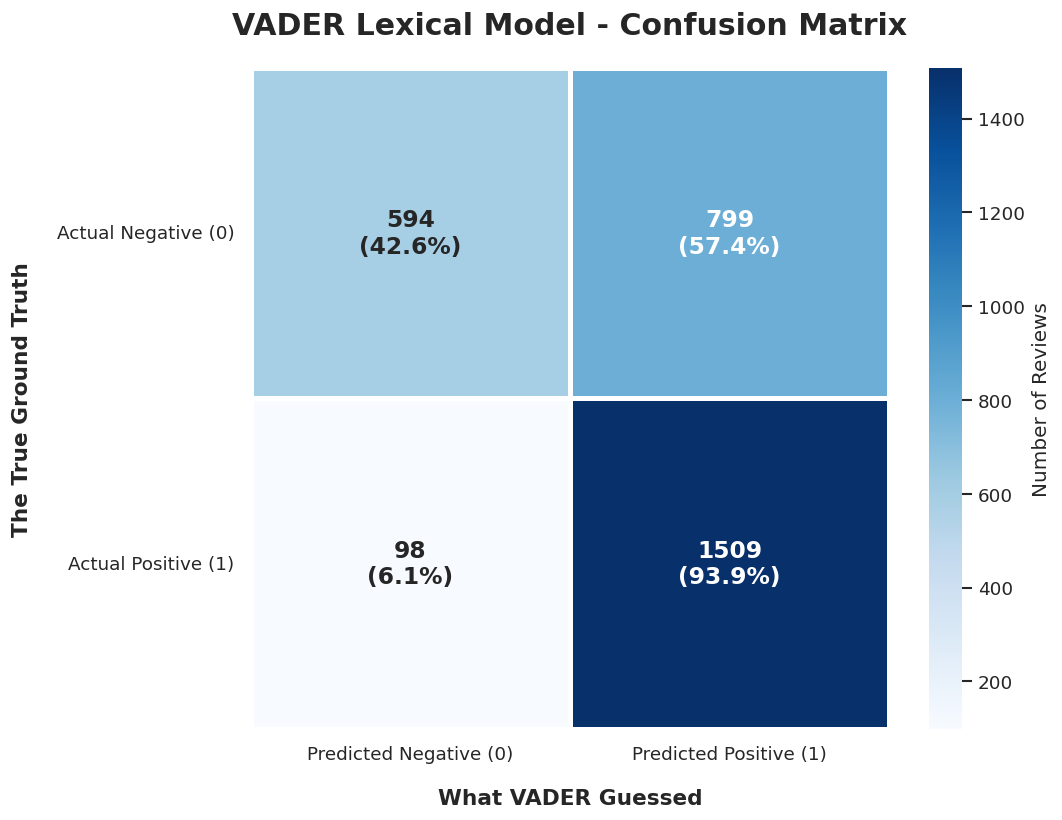

In [ ]:
# 1. Calculate the Confusion Matrix
cm_vader = confusion_matrix(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'])

# 2. ENHANCEMENT: Calculate percentages for richer data
# This allows us to see the recall/accuracy per class at a glance
cm_percentages = cm_vader.astype('float') / cm_vader.sum(axis=1)[:, np.newaxis]
annotations = [f"{count}\n({pct:.1%})" for count, pct in zip(cm_vader.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (dpi=120 for sharpness)
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Clean background to make the blue pop

# 4. Create the Enhanced Heatmap
# Using 'Blues' cmap and white thick linewidths for a modern UI look
ax = sns.heatmap(cm_vader,
                 annot=annotations,
                 fmt='',
                 cmap='Blues',
                 linewidths=3,
                 linecolor='white',
                 annot_kws={"size": 14, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Labeling
plt.title('VADER Lexical Model - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What VADER Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style adjustment for ticks
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Custom AFINN Model (From Scratch)**

In [ ]:
import urllib.request
import re
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

tqdm.pandas(desc="AFINN Scoring Progress")

# 1. Download the raw AFINN dictionary from scratch
print("Downloading raw AFINN dictionary...")
url = "https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt"
response = urllib.request.urlopen(url)
raw_afinn_data = response.read().decode('utf-8').split('\n')

# 2. Build the dictionary from scratch
afinn_dict = {}
for line in raw_afinn_data:
    if '\t' in line:
        word, score = line.split('\t')
        afinn_dict[word.strip()] = int(score.strip())
print(f"Loaded {len(afinn_dict)} words into our Custom AFINN Dictionary.")

# 3. Define Negation Words
negation_words = {'not', 'no', 'never', 'none', 'neither', 'cannot', "isn't", "wasn't", "aren't", "doesn't", "don't", "won't", "wouldn't", "couldn't", "shouldn't", "can't"}

# 4. Create the Custom Scoring Function WITH NEGATION logic
def custom_afinn_scorer(text):
    # Lowercase the text and split it into clean words using regex
    words = re.findall(r'\b\w+\b', str(text).lower())

    total_score = 0

    # Loop through words using an index so we can look backward
    for i in range(len(words)):
        word = words[i]

        # Check if the word is in our AFINN dictionary
        if word in afinn_dict:
            word_score = afinn_dict[word]

            # NEGATION RULE: Check if the word BEFORE it was a negation word
            if i > 0 and words[i-1] in negation_words:
                word_score = word_score * -1  # Flip the score! (e.g., "not good" -> 3 becomes -3)

            total_score += word_score

    # Final prediction: Positive if total > 0, else Negative
    return 1 if total_score > 0 else 0

print("\nRunning Custom AFINN Classifier on Raw Text_Cleaned...")
df_sentiment['AFINN_Pred'] = df_sentiment['Text_Cleaned'].progress_apply(custom_afinn_scorer)
# 5. Grade the Model
afinn_acc = accuracy_score(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'])

print("\n" + "="*60)
print("CUSTOM AFINN MODEL REPORT CARD")
print("="*60)
print(f"Overall Accuracy: {afinn_acc * 100:.2f}%\n")
print(classification_report(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'], target_names=['Negative (0)', 'Positive (1)']))



Loaded 2477 words into our Custom AFINN Dictionary.

Running Custom AFINN Classifier on Raw Text_Cleaned...


AFINN Scoring Progress:   0%|          | 0/3000 [00:00<?, ?it/s]


CUSTOM AFINN MODEL REPORT CARD
Overall Accuracy: 70.90%

              precision    recall  f1-score   support

Negative (0)       0.83      0.47      0.60      1393
Positive (1)       0.67      0.92      0.77      1607

    accuracy                           0.71      3000
   macro avg       0.75      0.69      0.69      3000
weighted avg       0.74      0.71      0.69      3000



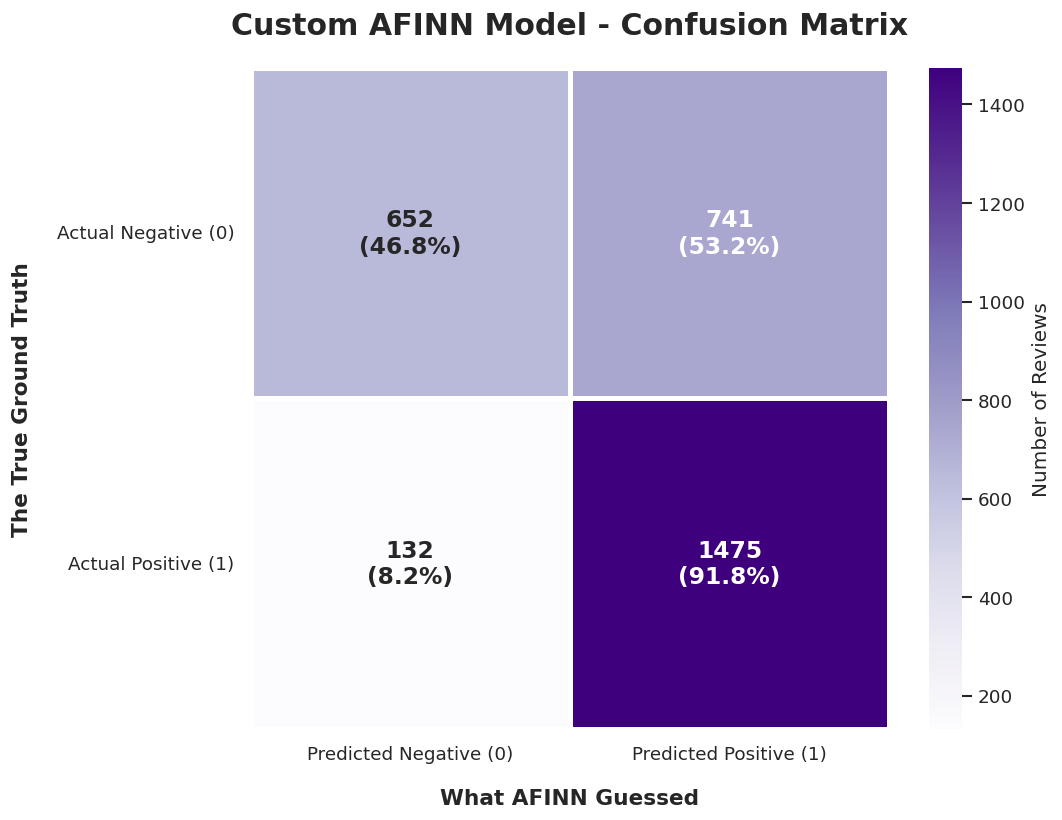

In [ ]:
# 1. Generate the matrix
cm_afinn = confusion_matrix(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'])

# 2. ENHANCEMENT: Calculate percentages for the annotations
# This creates labels like "150\n(85.5%)" instead of just "150"
cm_percentages = cm_afinn.astype('float') / cm_afinn.sum(axis=1)[:, np.newaxis]
annotations = [f"{count}\n({pct:.1%})" for count, pct in zip(cm_afinn.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (added dpi=120 for a much sharper, high-res image)
plt.figure(figsize=(9, 7), dpi=120)

# Removed the grid background because heatmaps look cleaner without it
sns.set_theme(style="white")

# 4. The Heatmap (Using 'Purples' colormap)
# Changed linecolor to white and made them thicker for a modern "tile" look
ax = sns.heatmap(cm_afinn,
                 annot=annotations,
                 fmt='', # Set to empty string since our annotations are custom strings now
                 cmap='Purples',
                 linewidths=3,
                 linecolor='white',
                 annot_kws={"size": 14, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Enhanced Typography and Spacing
# Added 'pad' and 'labelpad' to push the titles away from the graph slightly so it doesn't look cramped
plt.title('Custom AFINN Model - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What AFINN Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Ensure tick labels are readable and y-labels stay perfectly horizontal
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

# Ensures nothing gets cut off at the edges of the image
plt.tight_layout()
plt.show()

# **Phase 3 Machine Learning-Based Modelling**

# **1 SVM Experiment  (TF-IDF)**

In [ ]:
import pickle
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Feature Generation (Specific to Process 1: Lemmatization)
print("Generating TF-IDF Features for Text_Cleaned Process...")
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

# We use the new general dataframe and the specific Text_Cleaned column
X = tfidf_vectorizer.fit_transform(df_sentiment['Text_Cleaned'])
y = df_sentiment['Majority_Truth'].values

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split: Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

# 3. Initialize and Train the SVM
print("\nTraining SVM Model...")
svm_tfidf = SVC(kernel='linear', C=1.0)

with tqdm(total=1, desc="SVM Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    svm_tfidf.fit(X_train, y_train)
    pbar.update(1)

# 4. Make Predictions
print("\nGenerating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    y_pred = svm_tfidf.predict(X_test)
    pbar.update(1)

print("\nProcess Complete")

# --- Results Text Output ---
tfidf_acc = accuracy_score(y_test, y_pred)
print("\n" + "═"*60)
print(f"SVM EXPERIMENT: TF-IDF")
print("═"*60)
print(f"Final Accuracy: {tfidf_acc * 100:.2f}%")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═" * 60 + "\n")

Generating TF-IDF Features for Text_Cleaned Process...
Data Split: Training: 2400 | Testing: 600

Training SVM Model...


SVM Fitting:   0%|          | 00:00


Generating Predictions...


Predicting:   0%|          | 00:00


Process Complete

════════════════════════════════════════════════════════════
SVM EXPERIMENT: TF-IDF
════════════════════════════════════════════════════════════
Final Accuracy: 80.67%

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.8144    0.7926    0.8034       299
Positive (1)     0.7994    0.8206    0.8098       301

    accuracy                         0.8067       600
   macro avg     0.8069    0.8066    0.8066       600
weighted avg     0.8069    0.8067    0.8066       600

════════════════════════════════════════════════════════════



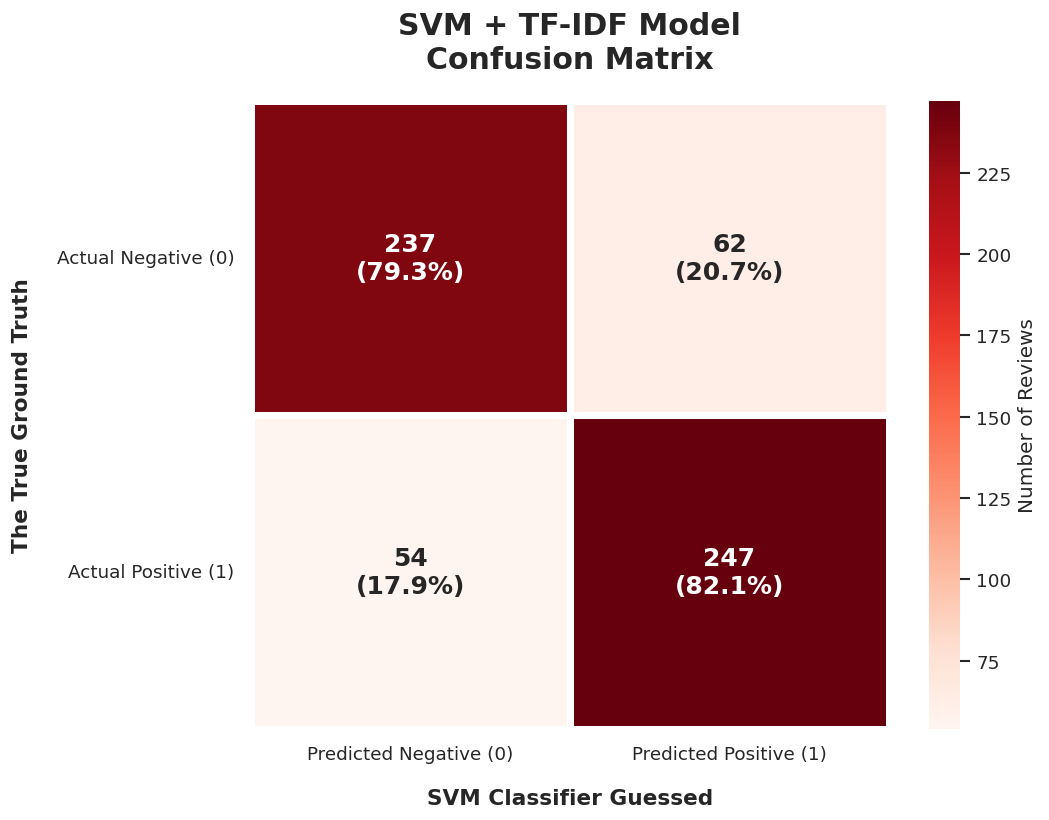

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate the raw Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. ENHANCEMENT: Generate annotations with Counts + Percentages
# (axis=1 calculates percentages relative to the ACTUAL class)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup for high-quality output
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Remove gridlines from the background

# 4. Create the Heatmap (Using 'Reds' and thick white borders)
ax = sns.heatmap(cm,
                 annot=annotations,
                 fmt='', # Use empty string for our custom annotations
                 cmap='Reds', # Apply the requested Red theme
                 linewidths=4, # Thicker lines look very modern
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Labeling and Typography
plt.title('SVM + TF-IDF Model\nConfusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('SVM Classifier Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style tick labels for readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0) # Keep Y-axis labels horizontal

plt.tight_layout()
plt.show()

# **2 SVM Experiment (GloVe Vectors)**

In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Feature Generation Function (Internal)
def get_glove_vector(text, model, vector_size=100):
    words = str(text).split()
    # Pull vectors for words that exist in the pre-loaded GloVe embeddings
    vectors = [model[word] for word in words if word in model]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# 2. Vectorize the 'Text_Cleaned' Column
print("Step 1: Transforming 'Text_Cleaned' into GloVe Vectors...")
X_list = []
for text in tqdm(df_sentiment['Text_Cleaned'], desc="Vectorizing"):
    X_list.append(get_glove_vector(text, embeddings_dict))

X = np.array(X_list)
y = df_sentiment['Majority_Truth'].values

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split Complete: {X_train.shape[0]} training samples.")

# 4. Initialize and Train SVM (RBF Kernel)
print("\nStep 2: Training SVM (RBF Kernel) on GloVe Features...")
svm_glove = SVC(kernel='rbf', C=1.0)

with tqdm(total=1, desc="SVM Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    svm_glove.fit(X_train, y_train)
    pbar.update(1)

# 5. Make Predictions & Report Results
print("\nStep 3: Generating Results...")
y_pred = svm_glove.predict(X_test)
glove_acc = accuracy_score(y_test, y_pred)

print("\n" + "═"*60)
print("SVM EXPERIMENT: GLOVE + LEMMATIZATION")
print("═"*60)
print(f"Accuracy Score: {glove_acc * 100:.2f}%")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Step 1: Transforming 'Text_Cleaned' into GloVe Vectors...


Vectorizing:   0%|          | 0/3000 [00:00<?, ?it/s]

Data Split Complete: 2400 training samples.

Step 2: Training SVM (RBF Kernel) on GloVe Features...


SVM Fitting:   0%|          | 00:00


Step 3: Generating Results...

════════════════════════════════════════════════════════════
SVM EXPERIMENT: GLOVE + LEMMATIZATION
════════════════════════════════════════════════════════════
Accuracy Score: 74.67%

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7838    0.6789    0.7276       299
Positive (1)     0.7185    0.8140    0.7632       301

    accuracy                         0.7467       600
   macro avg     0.7511    0.7464    0.7454       600
weighted avg     0.7510    0.7467    0.7455       600

════════════════════════════════════════════════════════════


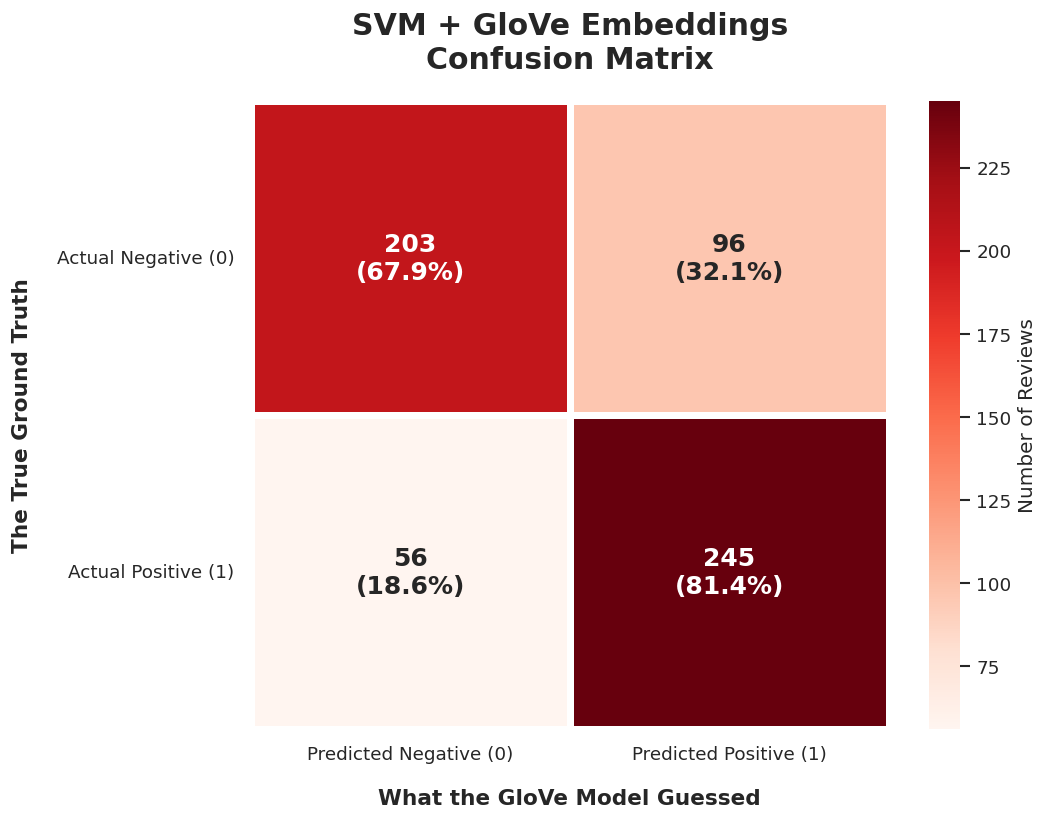

In [ ]:
cm_glove = confusion_matrix(y_test, y_pred)

# 2. ENHANCEMENT: Generate dual annotations (Count + Percentage)
# Percentages help show where the model is biased toward a specific class
cm_percentages = cm_glove.astype('float') / cm_glove.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_glove.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (High-Resolution)
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Clean background

# 4. Create the Enhanced Red Heatmap
# Using thicker white linewidths for a modern "dashboard" look
ax = sns.heatmap(cm_glove,
                 annot=annotations,
                 fmt='',
                 cmap='Reds',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Typography
plt.title('SVM + GloVe Embeddings\nConfusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What the GloVe Model Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style tick labels
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Linear Regression Model +TF-IDF**


In [ ]:
import numpy as np
from tqdm.auto import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# 1. Feature Generation (Reading directly from the Text_Cleaned column)
print("Generating TF-IDF Features from 'Text_Cleaned'...")
# We use the same parameters as the SVM to keep the comparison fair
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

with tqdm(total=1, desc="Vectorizing Text") as pbar:
    # Use the general dataframe name you defined
    X = tfidf_vectorizer.fit_transform(df_sentiment['Text_Cleaned'])
    y = df_sentiment['Majority_Truth'].values
    pbar.update(1)

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split: Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

# 3. Train Linear Regression
print(f"\nTraining Linear Regression Model...")
lin_reg = LinearRegression()

with tqdm(total=1, desc="Regression Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Linear Regression treats y as continuous values (0.0 to 1.0)
    lin_reg.fit(X_train, y_train)
    pbar.update(1)

# 4. Predict & Threshold
print("\nGenerating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Get raw decimal scores (e.g. 0.85, 0.12)
    raw_predictions = lin_reg.predict(X_test)

    # Convert to Binary Labels: >= 0.5 is Positive (1), else Negative (0)
    y_pred_binary = (raw_predictions >= 0.5).astype(int)
    pbar.update(1)

# 5. Results Output
reg_acc = accuracy_score(y_test, y_pred_binary)
mse = mean_squared_error(y_test, raw_predictions)

print("\n" + "═"*60)
print("FINAL MODEL: LINEAR REGRESSION + TF-IDF (LEMMATIZATION)")
print("═"*60)
print(f"Accuracy Score (Thresholded): {reg_acc * 100:.2f}%")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred_binary, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Generating TF-IDF Features from 'Text_Cleaned'...


Vectorizing Text:   0%|          | 0/1 [00:00<?, ?it/s]

Data Split: Training: 2400 | Testing: 600

Training Linear Regression Model...


Regression Fitting:   0%|          | 00:00


Generating Predictions...


Predicting:   0%|          | 00:00


════════════════════════════════════════════════════════════
FINAL MODEL: LINEAR REGRESSION + TF-IDF (LEMMATIZATION)
════════════════════════════════════════════════════════════
Accuracy Score (Thresholded): 64.17%
Mean Squared Error (MSE):     0.6636

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.6409    0.6388    0.6399       299
Positive (1)     0.6424    0.6445    0.6434       301

    accuracy                         0.6417       600
   macro avg     0.6417    0.6417    0.6417       600
weighted avg     0.6417    0.6417    0.6417       600

════════════════════════════════════════════════════════════


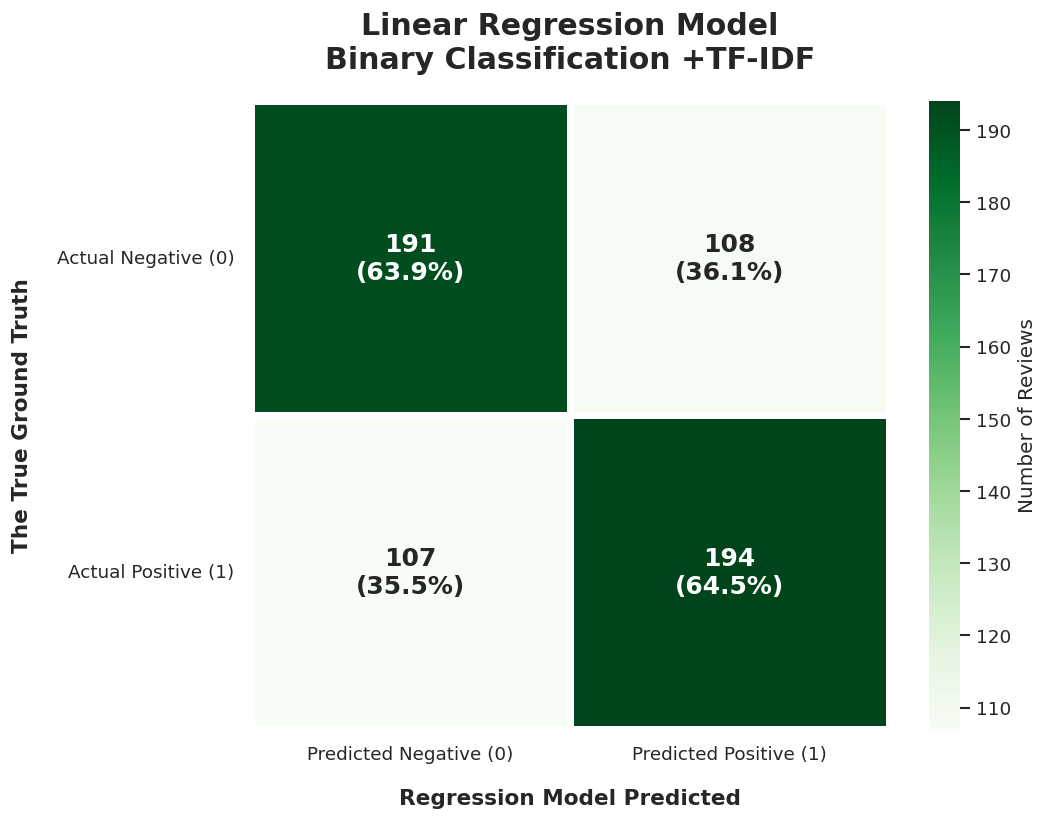

In [ ]:
# 1. Calculate Matrix
cm_reg = confusion_matrix(y_test, y_pred_binary)

# 2. Calculate Percentages
cm_percentages = cm_reg.astype('float') / cm_reg.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_reg.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white")

# 4. Heatmap (Using 'Greens' and white borders)
ax = sns.heatmap(cm_reg,
                 annot=annotations,
                 fmt='',
                 cmap='Greens',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Labels & Title
plt.title('Linear Regression Model\nBinary Classification +TF-IDF', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Regression Model Predicted', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Linear Regression Model +GLOVE**


In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# 1. Feature Generation Function (Internal)
def get_glove_vector(text, model, vector_size=100):
    words = str(text).split()
    # Pull vectors for words that exist in your pre-loaded glove_dict
    vectors = [model[word] for word in words if word in model]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# 2. Vectorize the 'Text_Cleaned' Column
print("Step 1: Transforming 'Text_Cleaned' into GloVe Vectors...")
X_list = []
# Using your general dataframe name: df_sentiment
for text in tqdm(df_sentiment['Text_Cleaned'], desc="Vectorizing"):
    X_list.append(get_glove_vector(text, glove_dict)) # Using glove_dict as defined in your loading cell

X = np.array(X_list)
y = df_sentiment['Majority_Truth'].values

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split Complete: {X_train.shape[0]} training samples.")

# 4. Train Linear Regression
print(f"\nStep 2: Training Linear Regression on GloVe vectors...")
lin_reg = LinearRegression()

with tqdm(total=1, desc="Regression Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    lin_reg.fit(X_train, y_train)
    pbar.update(1)

# 5. Predict & Threshold
print("Step 3: Generating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Linear Regression outputs continuous numbers
    raw_predictions = lin_reg.predict(X_test)

    # Thresholding: If the predicted value is >= 0.5, classify as Positive (1)
    y_pred_binary = (raw_predictions >= 0.5).astype(int)
    pbar.update(1)

# 6. Calculate & Display Metrics
reg_acc_glove = accuracy_score(y_test, y_pred_binary)
mse = mean_squared_error(y_test, raw_predictions)

print("\n" + "═"*60)
print("FINAL MODEL: LINEAR REGRESSION (GLOVE + LEMMATIZATION)")
print("═"*60)
print(f"Accuracy Score (Thresholded): {reg_acc_glove * 100:.2f}%")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred_binary, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Step 1: Transforming 'Text_Cleaned' into GloVe Vectors...


Vectorizing:   0%|          | 0/3000 [00:00<?, ?it/s]

Data Split Complete: 2400 training samples.

Step 2: Training Linear Regression on GloVe vectors...


Regression Fitting:   0%|          | 00:00

Step 3: Generating Predictions...


Predicting:   0%|          | 00:00


════════════════════════════════════════════════════════════
FINAL MODEL: LINEAR REGRESSION (GLOVE + LEMMATIZATION)
════════════════════════════════════════════════════════════
Accuracy Score (Thresholded): 76.33%
Mean Squared Error (MSE):     0.1681

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7855    0.7224    0.7526       299
Positive (1)     0.7446    0.8040    0.7732       301

    accuracy                         0.7633       600
   macro avg     0.7650    0.7632    0.7629       600
weighted avg     0.7650    0.7633    0.7629       600

════════════════════════════════════════════════════════════


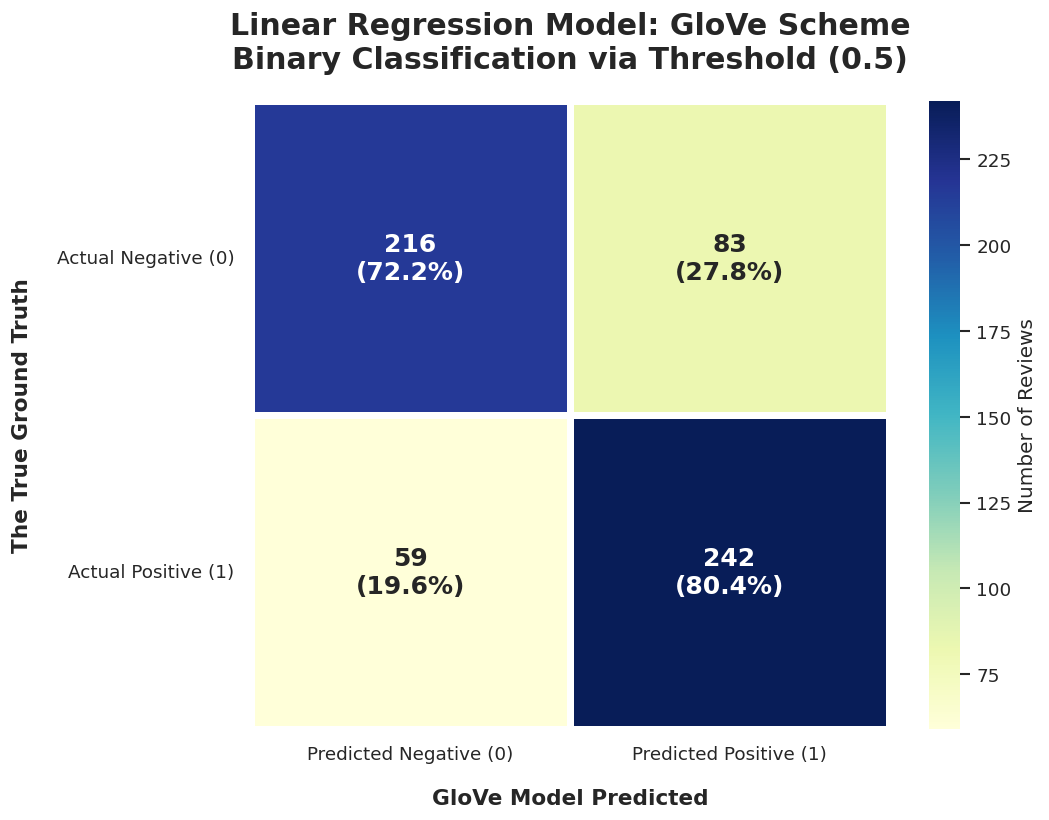

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate Matrix
# Assuming y_test and y_pred_binary are from your GloVe Regression run
cm_glove_reg = confusion_matrix(y_test, y_pred_binary)

# 2. Calculate Percentages for the annotations
cm_percentages = cm_glove_reg.astype('float') / cm_glove_reg.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_glove_reg.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white")

# 4. Heatmap (Using 'YlGnBu' to differentiate from the TF-IDF 'Greens')
ax = sns.heatmap(cm_glove_reg,
                 annot=annotations,
                 fmt='',
                 cmap='YlGnBu',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Labels & Title specifically for GloVe
plt.title('Linear Regression Model: GloVe Scheme\nBinary Classification via Threshold (0.5)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('GloVe Model Predicted', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# **final report (text cleansing)**

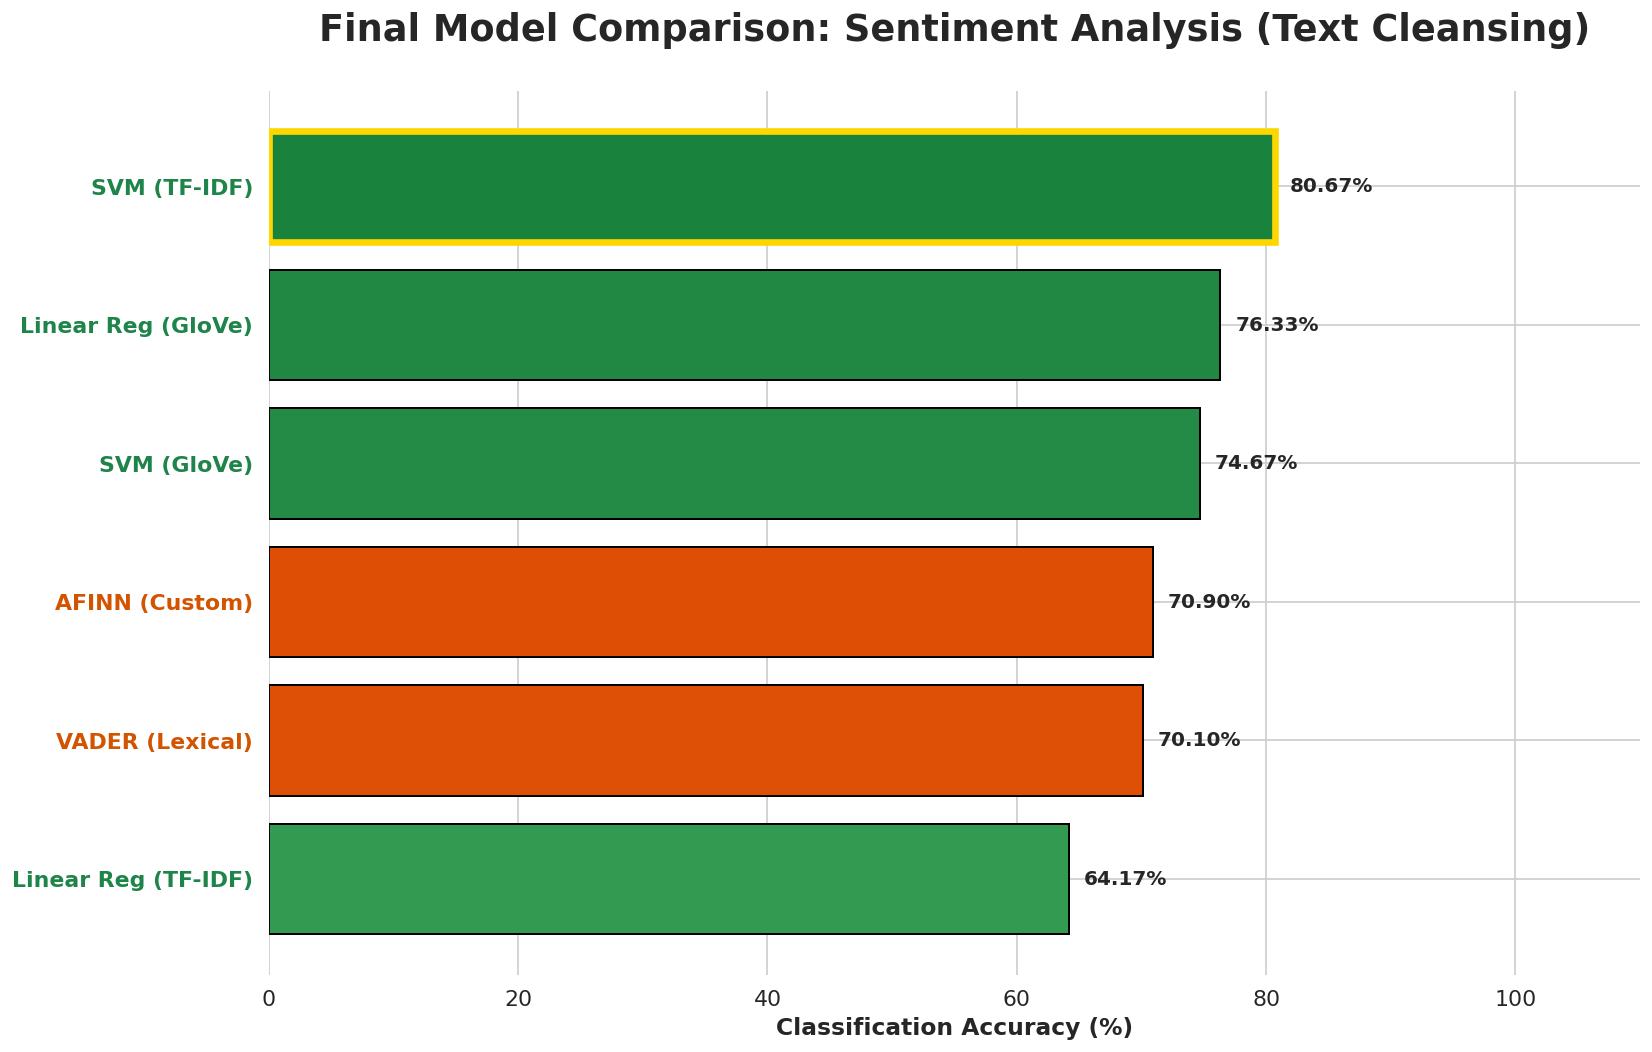


════════════════════════════════════════════════════════════
🏁 FINAL PROJECT RANKING
════════════════════════════════════════════════════════════
  Model Category          Model Name  Accuracy %
Machine Learning        SVM (TF-IDF)       80.67
Machine Learning  Linear Reg (GloVe)       76.33
Machine Learning         SVM (GloVe)       74.67
         Lexical      AFINN (Custom)       70.90
         Lexical     VADER (Lexical)       70.10
Machine Learning Linear Reg (TF-IDF)       64.17
------------------------------------------------------------
THE best model: SVM (TF-IDF) (80.67%)
════════════════════════════════════════════════════════════


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare data with the 6 specific models from your code
# Note: Ensure you have run all previous cells so these variables exist
performance_df = pd.DataFrame({
    'Model Category': [
        'Lexical', 'Lexical',
        'Machine Learning', 'Machine Learning',
        'Machine Learning', 'Machine Learning'
    ],
    'Model Name': [
        'VADER (Lexical)',
        'AFINN (Custom)',
        'SVM (TF-IDF)',
        'SVM (GloVe)',
        'Linear Reg (TF-IDF)',
        'Linear Reg (GloVe)'
    ],
    'Accuracy': [
        vader_acc,     # From VADER cell
        afinn_acc,     # From AFINN cell
        tfidf_acc,     # From SVM TF-IDF cell
        glove_acc,     # From SVM GloVe cell
        reg_acc,       # From Linear Regression TF-IDF cell
        reg_acc_glove  # Re-named to distinguish GloVe Reg from TF-IDF Reg
    ]
})

# 2. Convert to percentages and sort
performance_df['Accuracy %'] = (performance_df['Accuracy'] * 100).round(2)
performance_df = performance_df.sort_values(by='Accuracy %', ascending=True).reset_index(drop=True)

# 3. Styling and Colors
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, ax = plt.subplots(figsize=(14, 9), dpi=120)

colors = []
for _, row in performance_df.iterrows():
    if row['Model Category'] == 'Machine Learning':
        # Gradient Green for ML models
        colors.append(plt.cm.Greens(0.3 + (row['Accuracy'] * 0.6)))
    else:
        # Gradient Orange/Red for Lexical models
        colors.append(plt.cm.Oranges(0.3 + (row['Accuracy'] * 0.6)))

# 4. Create Horizontal Bar Chart
bars = ax.barh(
    performance_df['Model Name'],
    performance_df['Accuracy %'],
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

# 5. Highlight the Best Model with a Gold Border
best_idx = performance_df['Accuracy %'].idxmax()
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)

# 6. Add Accuracy Labels at the end of each bar
for i, value in enumerate(performance_df['Accuracy %']):
    ax.text(
        value + 1.2,
        i,
        f'{value:.2f}%',
        va='center',
        fontweight='bold',
        fontsize=12
    )

# 7. Labels and Titles
ax.set_title('Final Model Comparison: Sentiment Analysis (Text Cleansing)', fontsize=22, fontweight='bold', pad=30)
ax.set_xlabel('Classification Accuracy (%)', fontweight='bold', fontsize=14)
ax.set_xlim(0, 110) # Leave room for labels

# Color the Y-axis labels by category
for i, cat in enumerate(performance_df['Model Category']):
    if cat == 'Lexical':
        ax.get_yticklabels()[i].set_color('#d35400') # Deep Orange
        ax.get_yticklabels()[i].set_weight('bold')
    else:
        ax.get_yticklabels()[i].set_color('#1e8449') # Deep Green
        ax.get_yticklabels()[i].set_weight('bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 8. Final Insight Output
best_model_name = performance_df.iloc[-1]['Model Name']
best_model_acc = performance_df.iloc[-1]['Accuracy %']

print("\n" + "═"*60)
print("🏁 FINAL PROJECT RANKING")
print("═"*60)
print(performance_df[['Model Category', 'Model Name', 'Accuracy %']].sort_values(by='Accuracy %', ascending=False).to_string(index=False))
print("-" * 60)
print(f"THE best model: {best_model_name} ({best_model_acc}%)")
print("═"*60)

# **_________________________________________**

#**Phase 3 part 3 (Stemming + Contraction Expansion) Modelling** **Lexical-Based Modelling**


#**The VADER Model**

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

# Initialize loading bar
tqdm.pandas(desc="VADER Scoring Progress")

print("Downloading VADER Lexicon...")
nltk.download('vader_lexicon', quiet=True)

# 1. Initialize the Model
vader_analyzer = SentimentIntensityAnalyzer()

# 2. Define the scoring logic
def get_vader_prediction(text):
    # VADER returns a dictionary of scores. We want the 'compound' score (-1 to 1)
    score_dict = vader_analyzer.polarity_scores(str(text))
    compound_score = score_dict['compound']

    # If the score is greater than 0, it's Positive (1). Otherwise, Negative (0).
    return 1 if compound_score > 0 else 0

print("Running VADER Classifier on Raw Text_Stemmed...")
# Apply the model to the original, untouched Text column
df_sentiment['VADER_Pred'] = df_sentiment['Text_Stemmed'].progress_apply(get_vader_prediction)

# 3. Grade the Model (Compare predictions to Ground Truth)
vader_acc = accuracy_score(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'])

print("\n" + "="*60)
print("VADER MODEL REPORT CARD")
print("="*60)
print(f"Overall Accuracy: {vader_acc * 100:.2f}%\n")
print("Detailed Breakdown:")
print(classification_report(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'], target_names=['Negative (0)', 'Positive (1)']))

Running VADER Classifier on Raw Text_Stemmed...


VADER Scoring Progress:   0%|          | 0/3000 [00:00<?, ?it/s]


VADER MODEL REPORT CARD
Overall Accuracy: 66.17%

Detailed Breakdown:
              precision    recall  f1-score   support

Negative (0)       0.81      0.35      0.49      1393
Positive (1)       0.62      0.93      0.75      1607

    accuracy                           0.66      3000
   macro avg       0.72      0.64      0.62      3000
weighted avg       0.71      0.66      0.63      3000



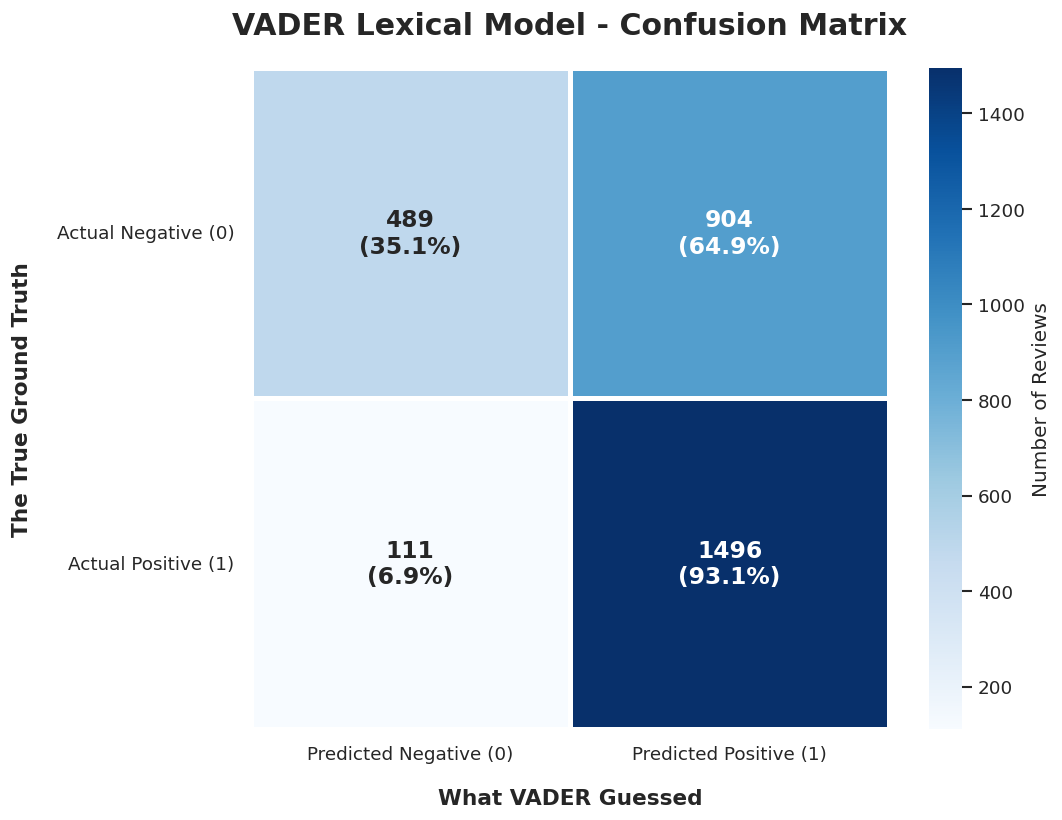

In [ ]:
# 1. Calculate the Confusion Matrix
cm_vader = confusion_matrix(df_sentiment['Majority_Truth'], df_sentiment['VADER_Pred'])

# 2. ENHANCEMENT: Calculate percentages for richer data
# This allows us to see the recall/accuracy per class at a glance
cm_percentages = cm_vader.astype('float') / cm_vader.sum(axis=1)[:, np.newaxis]
annotations = [f"{count}\n({pct:.1%})" for count, pct in zip(cm_vader.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (dpi=120 for sharpness)
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Clean background to make the blue pop

# 4. Create the Enhanced Heatmap
# Using 'Blues' cmap and white thick linewidths for a modern UI look
ax = sns.heatmap(cm_vader,
                 annot=annotations,
                 fmt='',
                 cmap='Blues',
                 linewidths=3,
                 linecolor='white',
                 annot_kws={"size": 14, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Labeling
plt.title('VADER Lexical Model - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What VADER Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style adjustment for ticks
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Custom AFINN Model (From Scratch)**

In [ ]:
import urllib.request
import re
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

tqdm.pandas(desc="AFINN Scoring Progress")

# 1. Download the raw AFINN dictionary from scratch
print("Downloading raw AFINN dictionary...")
url = "https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt"
response = urllib.request.urlopen(url)
raw_afinn_data = response.read().decode('utf-8').split('\n')

# 2. Build the dictionary from scratch
afinn_dict = {}
for line in raw_afinn_data:
    if '\t' in line:
        word, score = line.split('\t')
        afinn_dict[word.strip()] = int(score.strip())
print(f"Loaded {len(afinn_dict)} words into our Custom AFINN Dictionary.")

# 3. Define Negation Words
negation_words = {'not', 'no', 'never', 'none', 'neither', 'cannot', "isn't", "wasn't", "aren't", "doesn't", "don't", "won't", "wouldn't", "couldn't", "shouldn't", "can't"}

# 4. Create the Custom Scoring Function WITH NEGATION logic
def custom_afinn_scorer(text):
    # Lowercase the text and split it into clean words using regex
    words = re.findall(r'\b\w+\b', str(text).lower())

    total_score = 0

    # Loop through words using an index so we can look backward
    for i in range(len(words)):
        word = words[i]

        # Check if the word is in our AFINN dictionary
        if word in afinn_dict:
            word_score = afinn_dict[word]

            # NEGATION RULE: Check if the word BEFORE it was a negation word
            if i > 0 and words[i-1] in negation_words:
                word_score = word_score * -1  # Flip the score! (e.g., "not good" -> 3 becomes -3)

            total_score += word_score

    # Final prediction: Positive if total > 0, else Negative
    return 1 if total_score > 0 else 0

print("\nRunning Custom AFINN Classifier on Raw Text_Stemmed...")
df_sentiment['AFINN_Pred'] = df_sentiment['Text_Stemmed'].progress_apply(custom_afinn_scorer)
# 5. Grade the Model
afinn_acc = accuracy_score(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'])

print("\n" + "="*60)
print("CUSTOM AFINN MODEL REPORT CARD")
print("="*60)
print(f"Overall Accuracy: {afinn_acc * 100:.2f}%\n")
print(classification_report(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'], target_names=['Negative (0)', 'Positive (1)']))



Loaded 2477 words into our Custom AFINN Dictionary.

Running Custom AFINN Classifier on Raw Text_Stemmed...


AFINN Scoring Progress:   0%|          | 0/3000 [00:00<?, ?it/s]


CUSTOM AFINN MODEL REPORT CARD
Overall Accuracy: 66.33%

              precision    recall  f1-score   support

Negative (0)       0.79      0.37      0.51      1393
Positive (1)       0.63      0.92      0.74      1607

    accuracy                           0.66      3000
   macro avg       0.71      0.64      0.63      3000
weighted avg       0.70      0.66      0.63      3000



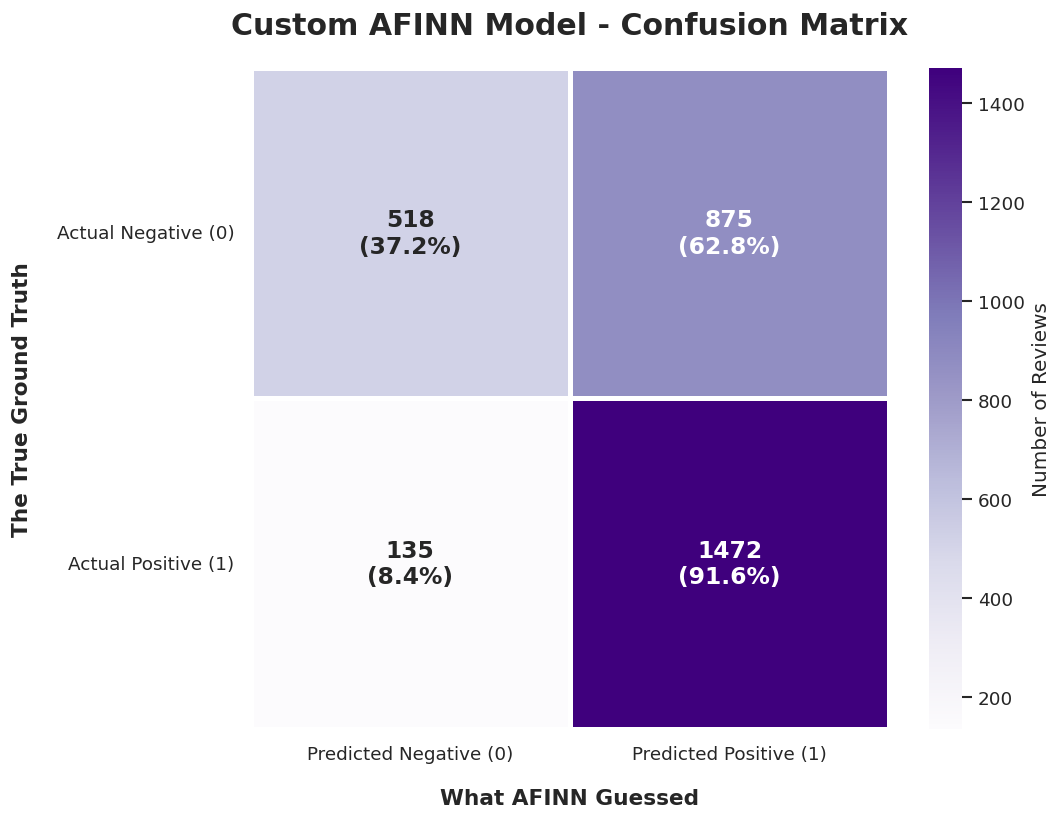

In [ ]:
# 1. Generate the matrix
cm_afinn = confusion_matrix(df_sentiment['Majority_Truth'], df_sentiment['AFINN_Pred'])

# 2. ENHANCEMENT: Calculate percentages for the annotations
# This creates labels like "150\n(85.5%)" instead of just "150"
cm_percentages = cm_afinn.astype('float') / cm_afinn.sum(axis=1)[:, np.newaxis]
annotations = [f"{count}\n({pct:.1%})" for count, pct in zip(cm_afinn.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (added dpi=120 for a much sharper, high-res image)
plt.figure(figsize=(9, 7), dpi=120)

# Removed the grid background because heatmaps look cleaner without it
sns.set_theme(style="white")

# 4. The Heatmap (Using 'Purples' colormap)
# Changed linecolor to white and made them thicker for a modern "tile" look
ax = sns.heatmap(cm_afinn,
                 annot=annotations,
                 fmt='', # Set to empty string since our annotations are custom strings now
                 cmap='Purples',
                 linewidths=3,
                 linecolor='white',
                 annot_kws={"size": 14, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Enhanced Typography and Spacing
# Added 'pad' and 'labelpad' to push the titles away from the graph slightly so it doesn't look cramped
plt.title('Custom AFINN Model - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What AFINN Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Ensure tick labels are readable and y-labels stay perfectly horizontal
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

# Ensures nothing gets cut off at the edges of the image
plt.tight_layout()
plt.show()

# **Phase 3 Machine Learning-Based Modelling**

# **1 SVM Experiment  (TF-IDF)**

In [ ]:
import pickle
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Feature Generation (Specific to Process 1: Text_Stemmed)
print("Generating TF-IDF Features for Text_Stemmed Process...")
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

# We use the new general dataframe and the specific Text_Stemmed column
X = tfidf_vectorizer.fit_transform(df_sentiment['Text_Stemmed'])
y = df_sentiment['Majority_Truth'].values

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split: Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

# 3. Initialize and Train the SVM
print("\nTraining SVM Model...")
svm_tfidf = SVC(kernel='linear', C=1.0)

with tqdm(total=1, desc="SVM Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    svm_tfidf.fit(X_train, y_train)
    pbar.update(1)

# 4. Make Predictions
print("\nGenerating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    y_pred = svm_tfidf.predict(X_test)
    pbar.update(1)

print("\nProcess Complete")

# --- Results Text Output ---
tfidf_acc = accuracy_score(y_test, y_pred)
print("\n" + "═"*60)
print(f"SVM EXPERIMENT: TF-IDF")
print("═"*60)
print(f"Final Accuracy: {tfidf_acc * 100:.2f}%")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═" * 60 + "\n")

Generating TF-IDF Features for Text_Stemmed Process...
Data Split: Training: 2400 | Testing: 600

Training SVM Model...


SVM Fitting:   0%|          | 00:00


Generating Predictions...


Predicting:   0%|          | 00:00


Process Complete

════════════════════════════════════════════════════════════
SVM EXPERIMENT: TF-IDF
════════════════════════════════════════════════════════════
Final Accuracy: 80.50%

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.8033    0.8060    0.8047       299
Positive (1)     0.8067    0.8040    0.8053       301

    accuracy                         0.8050       600
   macro avg     0.8050    0.8050    0.8050       600
weighted avg     0.8050    0.8050    0.8050       600

════════════════════════════════════════════════════════════



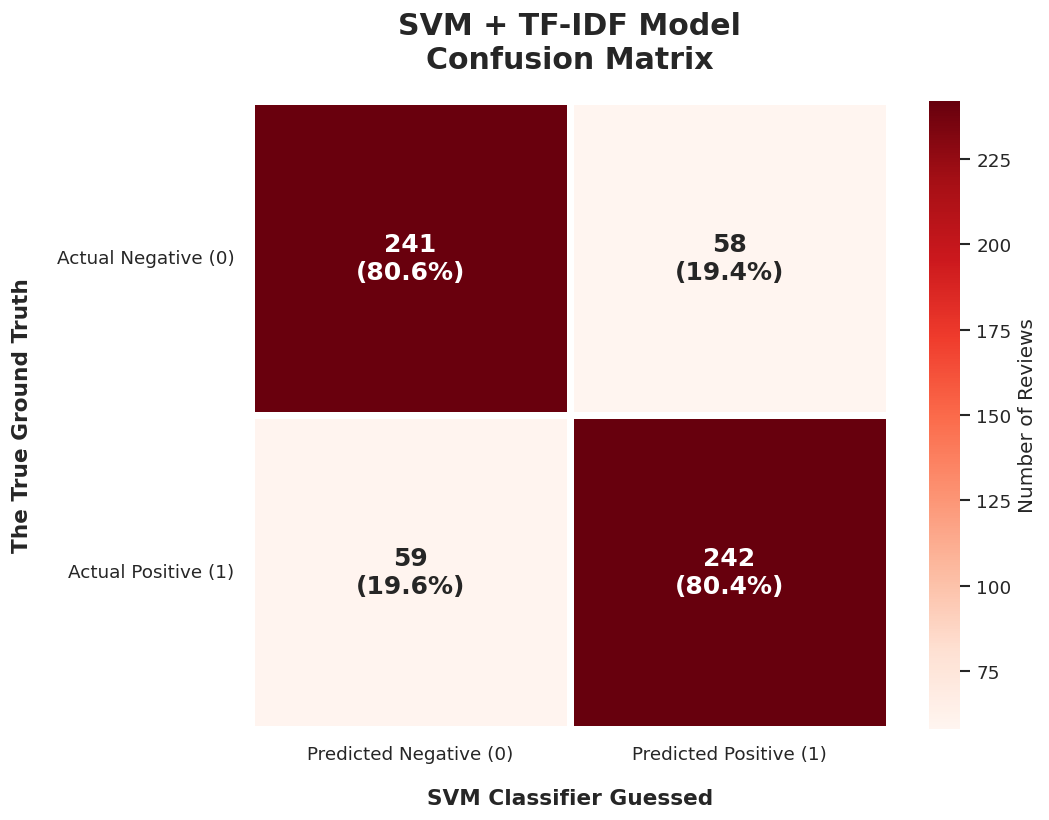

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate the raw Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. ENHANCEMENT: Generate annotations with Counts + Percentages
# (axis=1 calculates percentages relative to the ACTUAL class)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup for high-quality output
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Remove gridlines from the background

# 4. Create the Heatmap (Using 'Reds' and thick white borders)
ax = sns.heatmap(cm,
                 annot=annotations,
                 fmt='', # Use empty string for our custom annotations
                 cmap='Reds', # Apply the requested Red theme
                 linewidths=4, # Thicker lines look very modern
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Labeling and Typography
plt.title('SVM + TF-IDF Model\nConfusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('SVM Classifier Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style tick labels for readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0) # Keep Y-axis labels horizontal

plt.tight_layout()
plt.show()

# **2 SVM Experiment (GloVe Vectors)**

In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Feature Generation Function (Internal)
def get_glove_vector(text, model, vector_size=100):
    words = str(text).split()
    # Pull vectors for words that exist in the pre-loaded GloVe embeddings
    vectors = [model[word] for word in words if word in model]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# 2. Vectorize the 'Text_Stemmed' Column
print("Step 1: Transforming 'Text_Stemmed' into GloVe Vectors...")
X_list = []
for text in tqdm(df_sentiment['Text_Stemmed'], desc="Vectorizing"):
    X_list.append(get_glove_vector(text, embeddings_dict))

X = np.array(X_list)
y = df_sentiment['Majority_Truth'].values

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split Complete: {X_train.shape[0]} training samples.")

# 4. Initialize and Train SVM (RBF Kernel)
print("\nStep 2: Training SVM (RBF Kernel) on GloVe Features...")
svm_glove = SVC(kernel='rbf', C=1.0)

with tqdm(total=1, desc="SVM Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    svm_glove.fit(X_train, y_train)
    pbar.update(1)

# 5. Make Predictions & Report Results
print("\nStep 3: Generating Results...")
y_pred = svm_glove.predict(X_test)
glove_acc = accuracy_score(y_test, y_pred)

print("\n" + "═"*60)
print("SVM EXPERIMENT: GLOVE + LEMMATIZATION")
print("═"*60)
print(f"Accuracy Score: {glove_acc * 100:.2f}%")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Step 1: Transforming 'Text_Stemmed' into GloVe Vectors...


Vectorizing:   0%|          | 0/3000 [00:00<?, ?it/s]

Data Split Complete: 2400 training samples.

Step 2: Training SVM (RBF Kernel) on GloVe Features...


SVM Fitting:   0%|          | 00:00


Step 3: Generating Results...

════════════════════════════════════════════════════════════
SVM EXPERIMENT: GLOVE + LEMMATIZATION
════════════════════════════════════════════════════════════
Accuracy Score: 73.67%

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7660    0.6789    0.7199       299
Positive (1)     0.7134    0.7940    0.7516       301

    accuracy                         0.7367       600
   macro avg     0.7397    0.7365    0.7357       600
weighted avg     0.7396    0.7367    0.7358       600

════════════════════════════════════════════════════════════


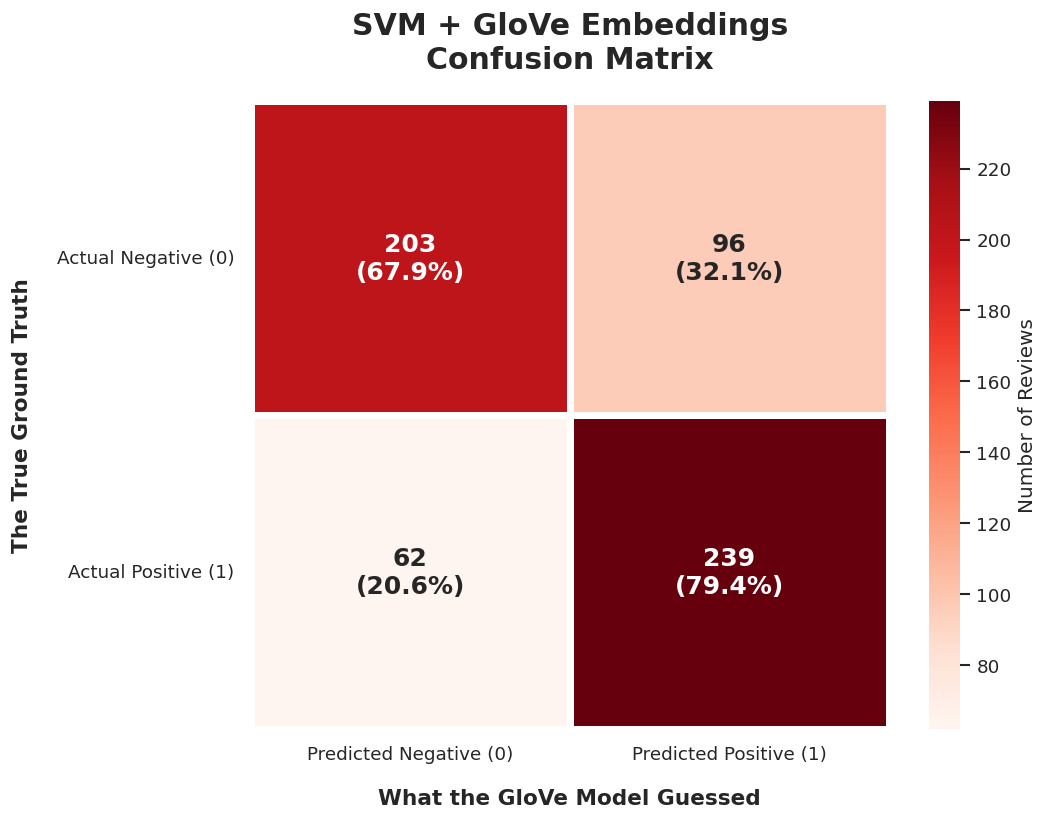

In [ ]:
cm_glove = confusion_matrix(y_test, y_pred)

# 2. ENHANCEMENT: Generate dual annotations (Count + Percentage)
# Percentages help show where the model is biased toward a specific class
cm_percentages = cm_glove.astype('float') / cm_glove.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_glove.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup (High-Resolution)
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white") # Clean background

# 4. Create the Enhanced Red Heatmap
# Using thicker white linewidths for a modern "dashboard" look
ax = sns.heatmap(cm_glove,
                 annot=annotations,
                 fmt='',
                 cmap='Reds',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Professional Typography
plt.title('SVM + GloVe Embeddings\nConfusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What the GloVe Model Guessed', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

# Style tick labels
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Linear Regression Model +TF-IDF**


In [ ]:
import numpy as np
from tqdm.auto import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# 1. Feature Generation (Reading directly from the Text_Stemmed column)
print("Generating TF-IDF Features from 'Text_Stemmed'...")
# We use the same parameters as the SVM to keep the comparison fair
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

with tqdm(total=1, desc="Vectorizing Text") as pbar:
    # Use the general dataframe name you defined
    X = tfidf_vectorizer.fit_transform(df_sentiment['Text_Stemmed'])
    y = df_sentiment['Majority_Truth'].values
    pbar.update(1)

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split: Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

# 3. Train Linear Regression
print(f"\nTraining Linear Regression Model...")
lin_reg = LinearRegression()

with tqdm(total=1, desc="Regression Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Linear Regression treats y as continuous values (0.0 to 1.0)
    lin_reg.fit(X_train, y_train)
    pbar.update(1)

# 4. Predict & Threshold
print("\nGenerating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Get raw decimal scores (e.g. 0.85, 0.12)
    raw_predictions = lin_reg.predict(X_test)

    # Convert to Binary Labels: >= 0.5 is Positive (1), else Negative (0)
    y_pred_binary = (raw_predictions >= 0.5).astype(int)
    pbar.update(1)

# 5. Results Output
reg_acc = accuracy_score(y_test, y_pred_binary)
mse = mean_squared_error(y_test, raw_predictions)

print("\n" + "═"*60)
print("FINAL MODEL: LINEAR REGRESSION + TF-IDF (LEMMATIZATION)")
print("═"*60)
print(f"Accuracy Score (Thresholded): {reg_acc * 100:.2f}%")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred_binary, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Generating TF-IDF Features from 'Text_Stemmed'...


Vectorizing Text:   0%|          | 0/1 [00:00<?, ?it/s]

Data Split: Training: 2400 | Testing: 600

Training Linear Regression Model...


Regression Fitting:   0%|          | 00:00


Generating Predictions...


Predicting:   0%|          | 00:00


════════════════════════════════════════════════════════════
FINAL MODEL: LINEAR REGRESSION + TF-IDF (LEMMATIZATION)
════════════════════════════════════════════════════════════
Accuracy Score (Thresholded): 64.67%
Mean Squared Error (MSE):     0.7153

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.6372    0.6756    0.6558       299
Positive (1)     0.6572    0.6179    0.6370       301

    accuracy                         0.6467       600
   macro avg     0.6472    0.6468    0.6464       600
weighted avg     0.6473    0.6467    0.6464       600

════════════════════════════════════════════════════════════


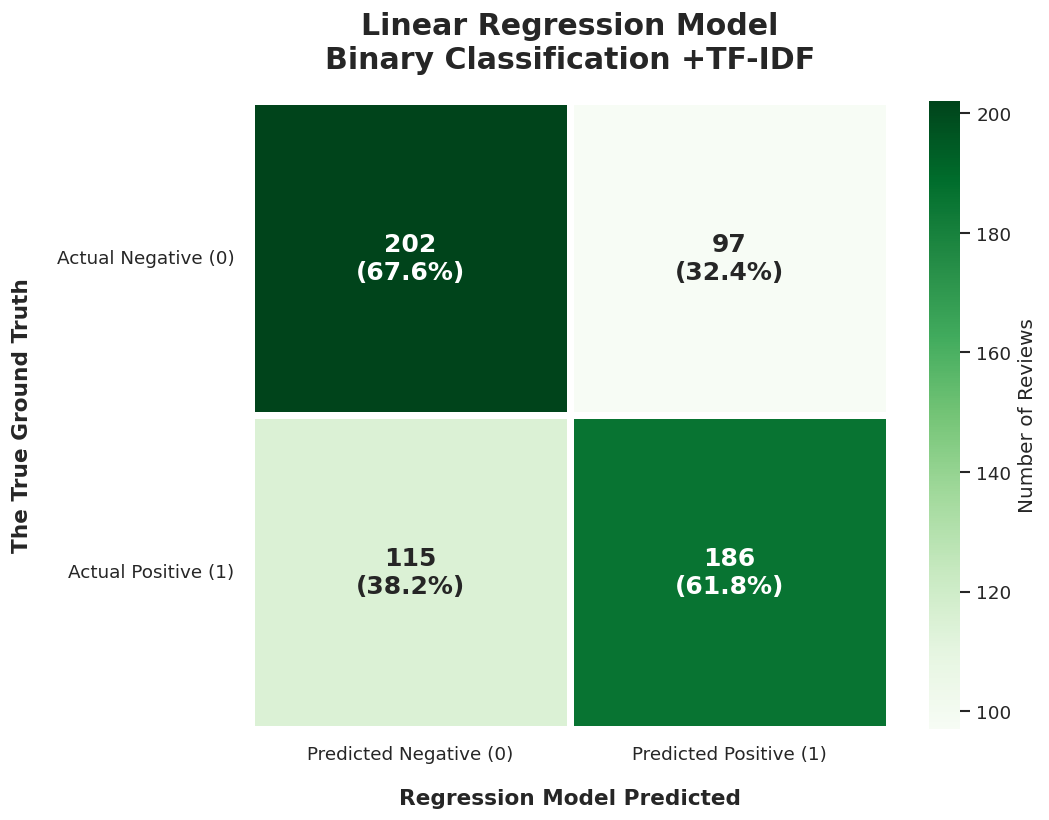

In [ ]:
# 1. Calculate Matrix
cm_reg = confusion_matrix(y_test, y_pred_binary)

# 2. Calculate Percentages
cm_percentages = cm_reg.astype('float') / cm_reg.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_reg.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white")

# 4. Heatmap (Using 'Greens' and white borders)
ax = sns.heatmap(cm_reg,
                 annot=annotations,
                 fmt='',
                 cmap='Greens',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Labels & Title
plt.title('Linear Regression Model\nBinary Classification +TF-IDF', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Regression Model Predicted', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

#**Linear Regression Model +GLOVE**


In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# 1. Feature Generation Function (Internal)
def get_glove_vector(text, model, vector_size=100):
    words = str(text).split()
    # Pull vectors for words that exist in your pre-loaded glove_dict
    vectors = [model[word] for word in words if word in model]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# 2. Vectorize the 'Text_Stemmed' Column
print("Step 1: Transforming 'Text_Stemmed' into GloVe Vectors...")
X_list = []
# Using your general dataframe name: df_sentiment
for text in tqdm(df_sentiment['Text_Stemmed'], desc="Vectorizing"):
    X_list.append(get_glove_vector(text, glove_dict)) # Using glove_dict as defined in your loading cell

X = np.array(X_list)
y = df_sentiment['Majority_Truth'].values

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Data Split Complete: {X_train.shape[0]} training samples.")

# 4. Train Linear Regression
print(f"\nStep 2: Training Linear Regression on GloVe vectors...")
lin_reg = LinearRegression()

with tqdm(total=1, desc="Regression Fitting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    lin_reg.fit(X_train, y_train)
    pbar.update(1)

# 5. Predict & Threshold
print("Step 3: Generating Predictions...")
with tqdm(total=1, desc="Predicting", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
    # Linear Regression outputs continuous numbers
    raw_predictions = lin_reg.predict(X_test)

    # Thresholding: If the predicted value is >= 0.5, classify as Positive (1)
    y_pred_binary = (raw_predictions >= 0.5).astype(int)
    pbar.update(1)

# 6. Calculate & Display Metrics
reg_acc_glove = accuracy_score(y_test, y_pred_binary)
mse = mean_squared_error(y_test, raw_predictions)

print("\n" + "═"*60)
print("FINAL MODEL: LINEAR REGRESSION (GLOVE + LEMMATIZATION)")
print("═"*60)
print(f"Accuracy Score (Thresholded): {reg_acc_glove * 100:.2f}%")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print("\nDetailed Classification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred_binary, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═"*60)

Step 1: Transforming 'Text_Stemmed' into GloVe Vectors...


Vectorizing:   0%|          | 0/3000 [00:00<?, ?it/s]

Data Split Complete: 2400 training samples.

Step 2: Training Linear Regression on GloVe vectors...


Regression Fitting:   0%|          | 00:00

Step 3: Generating Predictions...


Predicting:   0%|          | 00:00


════════════════════════════════════════════════════════════
FINAL MODEL: LINEAR REGRESSION (GLOVE + LEMMATIZATION)
════════════════════════════════════════════════════════════
Accuracy Score (Thresholded): 75.33%
Mean Squared Error (MSE):     0.1754

Detailed Classification Report:
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7649    0.7291    0.7466       299
Positive (1)     0.7429    0.7774    0.7597       301

    accuracy                         0.7533       600
   macro avg     0.7539    0.7533    0.7532       600
weighted avg     0.7538    0.7533    0.7532       600

════════════════════════════════════════════════════════════


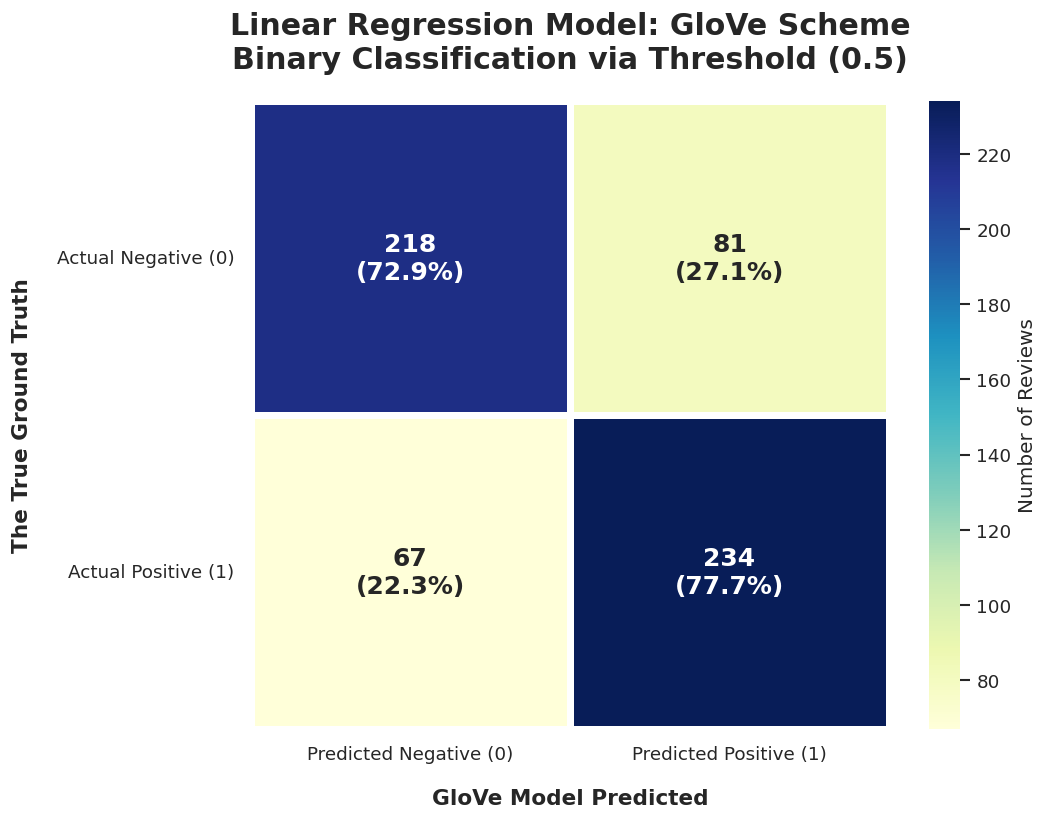

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate Matrix
# Assuming y_test and y_pred_binary are from your GloVe Regression run
cm_glove_reg = confusion_matrix(y_test, y_pred_binary)

# 2. Calculate Percentages for the annotations
cm_percentages = cm_glove_reg.astype('float') / cm_glove_reg.sum(axis=1)[:, np.newaxis]
annotations = [f"{count:,d}\n({pct:.1%})" for count, pct in zip(cm_glove_reg.flatten(), cm_percentages.flatten())]
annotations = np.asarray(annotations).reshape(2, 2)

# 3. Figure setup
plt.figure(figsize=(9, 7), dpi=120)
sns.set_theme(style="white")

# 4. Heatmap (Using 'YlGnBu' to differentiate from the TF-IDF 'Greens')
ax = sns.heatmap(cm_glove_reg,
                 annot=annotations,
                 fmt='',
                 cmap='YlGnBu',
                 linewidths=4,
                 linecolor='white',
                 annot_kws={"size": 15, "weight": "bold"},
                 cbar_kws={'label': 'Number of Reviews'},
                 xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
                 yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# 5. Labels & Title specifically for GloVe
plt.title('Linear Regression Model: GloVe Scheme\nBinary Classification via Threshold (0.5)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('GloVe Model Predicted', fontsize=13, fontweight='bold', labelpad=15)
plt.ylabel('The True Ground Truth', fontsize=13, fontweight='bold', labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# **final report (lemmatization)**

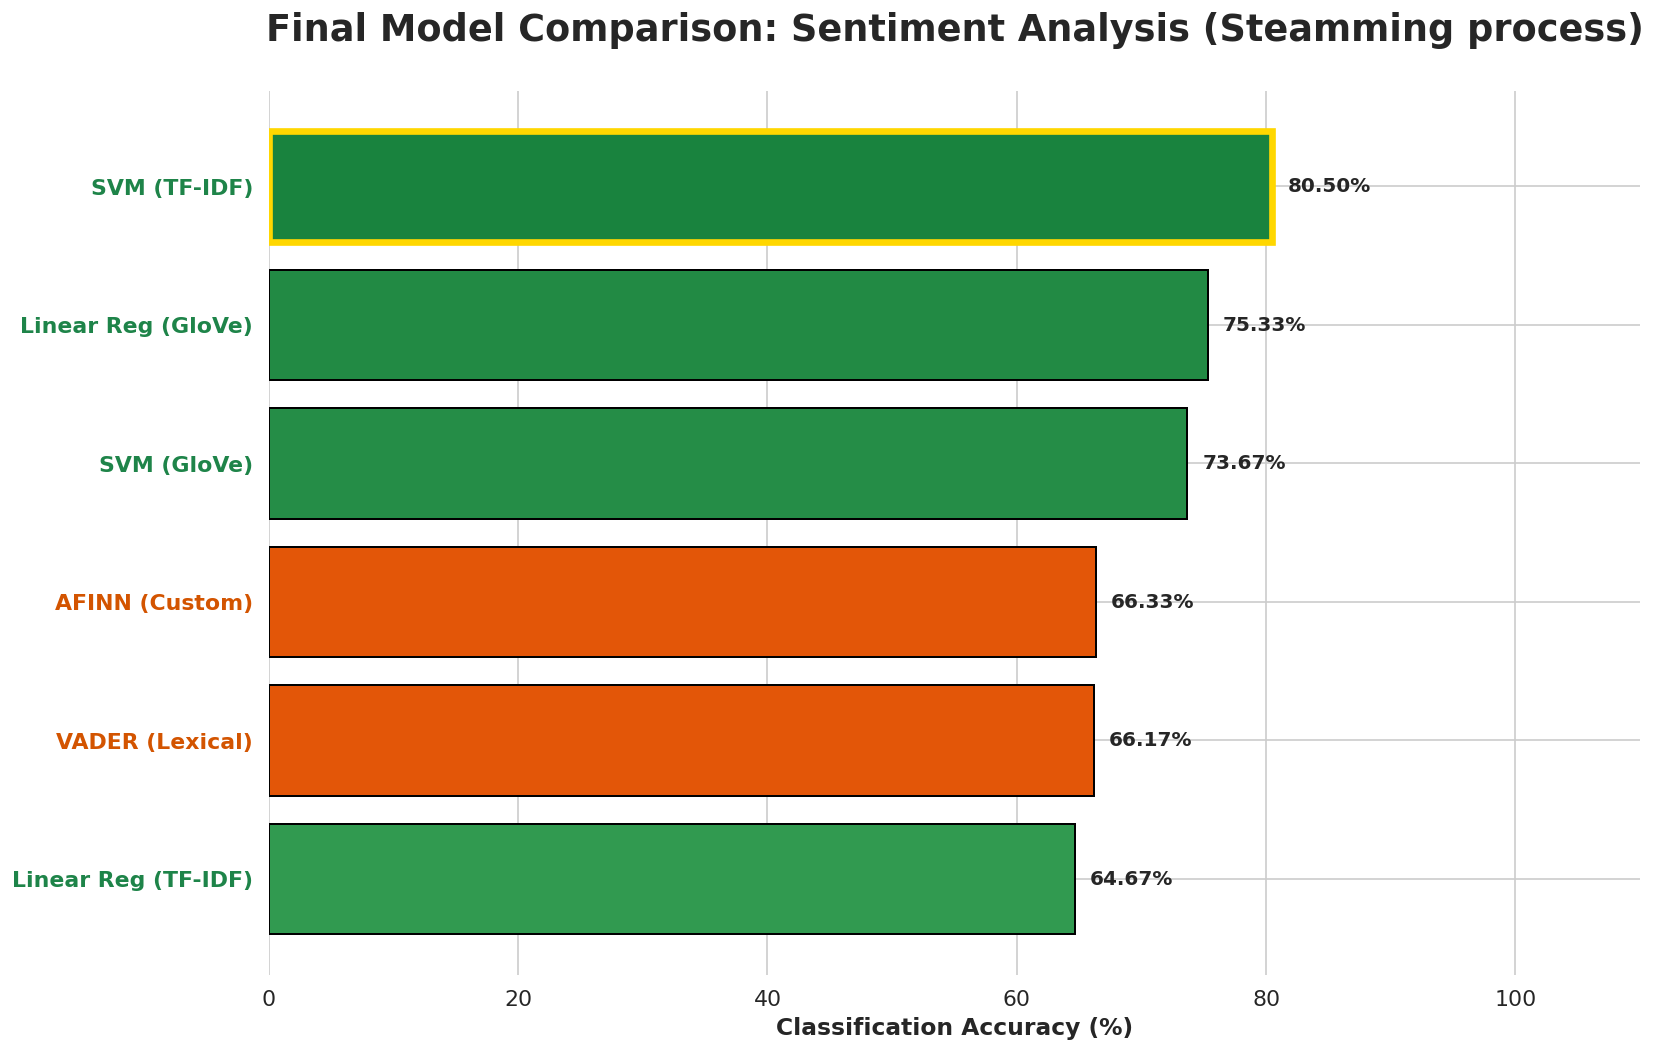


════════════════════════════════════════════════════════════
🏁 FINAL PROJECT RANKING
════════════════════════════════════════════════════════════
  Model Category          Model Name  Accuracy %
Machine Learning        SVM (TF-IDF)       80.50
Machine Learning  Linear Reg (GloVe)       75.33
Machine Learning         SVM (GloVe)       73.67
         Lexical      AFINN (Custom)       66.33
         Lexical     VADER (Lexical)       66.17
Machine Learning Linear Reg (TF-IDF)       64.67
------------------------------------------------------------
THE best model: SVM (TF-IDF) (80.5%)
════════════════════════════════════════════════════════════


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare data with the 6 specific models from your code
# Note: Ensure you have run all previous cells so these variables exist
performance_df = pd.DataFrame({
    'Model Category': [
        'Lexical', 'Lexical',
        'Machine Learning', 'Machine Learning',
        'Machine Learning', 'Machine Learning'
    ],
    'Model Name': [
        'VADER (Lexical)',
        'AFINN (Custom)',
        'SVM (TF-IDF)',
        'SVM (GloVe)',
        'Linear Reg (TF-IDF)',
        'Linear Reg (GloVe)'
    ],
    'Accuracy': [
        vader_acc,     # From VADER cell
        afinn_acc,     # From AFINN cell
        tfidf_acc,     # From SVM TF-IDF cell
        glove_acc,     # From SVM GloVe cell
        reg_acc,       # From Linear Regression TF-IDF cell
        reg_acc_glove  # Re-named to distinguish GloVe Reg from TF-IDF Reg
    ]
})

# 2. Convert to percentages and sort
performance_df['Accuracy %'] = (performance_df['Accuracy'] * 100).round(2)
performance_df = performance_df.sort_values(by='Accuracy %', ascending=True).reset_index(drop=True)

# 3. Styling and Colors
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, ax = plt.subplots(figsize=(14, 9), dpi=120)

colors = []
for _, row in performance_df.iterrows():
    if row['Model Category'] == 'Machine Learning':
        # Gradient Green for ML models
        colors.append(plt.cm.Greens(0.3 + (row['Accuracy'] * 0.6)))
    else:
        # Gradient Orange/Red for Lexical models
        colors.append(plt.cm.Oranges(0.3 + (row['Accuracy'] * 0.6)))

# 4. Create Horizontal Bar Chart
bars = ax.barh(
    performance_df['Model Name'],
    performance_df['Accuracy %'],
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

# 5. Highlight the Best Model with a Gold Border
best_idx = performance_df['Accuracy %'].idxmax()
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)

# 6. Add Accuracy Labels at the end of each bar
for i, value in enumerate(performance_df['Accuracy %']):
    ax.text(
        value + 1.2,
        i,
        f'{value:.2f}%',
        va='center',
        fontweight='bold',
        fontsize=12
    )

# 7. Labels and Titles
ax.set_title('Final Model Comparison: Sentiment Analysis (Steamming process)', fontsize=22, fontweight='bold', pad=30)
ax.set_xlabel('Classification Accuracy (%)', fontweight='bold', fontsize=14)
ax.set_xlim(0, 110) # Leave room for labels

# Color the Y-axis labels by category
for i, cat in enumerate(performance_df['Model Category']):
    if cat == 'Lexical':
        ax.get_yticklabels()[i].set_color('#d35400') # Deep Orange
        ax.get_yticklabels()[i].set_weight('bold')
    else:
        ax.get_yticklabels()[i].set_color('#1e8449') # Deep Green
        ax.get_yticklabels()[i].set_weight('bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 8. Final Insight Output
best_model_name = performance_df.iloc[-1]['Model Name']
best_model_acc = performance_df.iloc[-1]['Accuracy %']

print("\n" + "═"*60)
print("🏁 FINAL PROJECT RANKING")
print("═"*60)
print(performance_df[['Model Category', 'Model Name', 'Accuracy %']].sort_values(by='Accuracy %', ascending=False).to_string(index=False))
print("-" * 60)
print(f"THE best model: {best_model_name} ({best_model_acc}%)")
print("═"*60)

In [ ]:

df_sentiment.to_csv("/content/review_data.csv",index=False)

#

# **The Optimized SVM + TF-IDF Cell**

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

# 1. Feature Generation (Lemmatized Process)
print("⚙️ Generating TF-IDF Features for Lemmatized Process...")
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X = tfidf_vectorizer.fit_transform(df_sentiment['Text_Lemmatized'])
y = df_sentiment['Majority_Truth'].values

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"✅ Data Split: Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")

# 3. Define the Bayesian Search Space
# This hits your rubric requirement to handle over/underfitting via complexity/regularization
search_spaces = {
    'C': Real(0.1, 50.0, prior='log-uniform'),      # Regularization parameter
    'kernel': Categorical(['linear', 'rbf']),       # Testing approach changes (Linear -> RBF)
    'gamma': Real(1e-3, 1.0, prior='log-uniform')   # Kernel coefficient (Only impacts RBF)
}

# 4. Initialize the Optimizer
print("\n🚀 Setting up Bayesian Optimization...")
# Note: probability=True is required to calculate ROC-AUC later!
svm_base = SVC(probability=True, random_state=42)

# We use 10 iterations to save time. In a real corporate setting, you might run 50+.
n_iterations = 10
bayes_search = BayesSearchCV(
    estimator=svm_base,
    search_spaces=search_spaces,
    n_iter=n_iterations,
    cv=3,                 # 3-Fold Cross Validation
    scoring='f1_macro',   # Optimizing specifically for F1-Score (per your rubric)
    n_jobs=-1,            # Use all CPU cores
    random_state=42
)

# Custom Callback to make skopt work with tqdm
class TqdmSkoptCallback:
    def __init__(self, n_iter):
        self.pbar = tqdm(total=n_iter, desc="Bayesian Tuning", bar_format='{l_bar}{bar}| {elapsed} [{remaining} left]')
    def __call__(self, res):
        self.pbar.update(1)

# 5. Execute the Search
print(f"🧠 Commencing Search (Testing {n_iterations} different model architectures...)")
# This step takes time! The model is training itself multiple times.
bayes_search.fit(X_train, y_train, callback=TqdmSkoptCallback(n_iterations))

# 6. Extract the Best Model & Predict
best_svm = bayes_search.best_estimator_
print("\n🎯 Generating Predictions with the Champion Model...")
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1] # Get probabilities for ROC-AUC

# 7. Calculate Rubric Metrics
opt_acc = accuracy_score(y_test, y_pred)
opt_roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "═"*60)
print(f" OPTIMIZED SVM EXPERIMENT: TF-IDF")
print("═"*60)
print("BEST HYPERPARAMETERS FOUND:")
for param, value in bayes_search.best_params_.items():
    print(f" - {param}: {value}")
print("-" * 30)
print(f"Final Accuracy: {opt_acc * 100:.2f}%")
print(f"ROC-AUC Score:  {opt_roc_auc:.4f}")
print("\nDetailed Classification Report (includes Precision/Recall/F1):")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)'], digits=4))
print("═" * 60 + "\n")

⚙️ Generating TF-IDF Features for Lemmatized Process...
✅ Data Split: Training: 2400 | Testing: 600

🚀 Setting up Bayesian Optimization...
🧠 Commencing Search (Testing 10 different model architectures...)


Bayesian Tuning:   0%|          | 00:00 [? left]


🎯 Generating Predictions with the Champion Model...

════════════════════════════════════════════════════════════
 OPTIMIZED SVM EXPERIMENT: TF-IDF
════════════════════════════════════════════════════════════
BEST HYPERPARAMETERS FOUND:
 - C: 1.5870463392513299
 - gamma: 0.5703843027403095
 - kernel: linear
------------------------------
Final Accuracy: 82.17%
ROC-AUC Score:  0.8821

Detailed Classification Report (includes Precision/Recall/F1):
------------------------------
              precision    recall  f1-score   support

Negative (0)     0.8097    0.8395    0.8243       299
Positive (1)     0.8345    0.8040    0.8190       301

    accuracy                         0.8217       600
   macro avg     0.8221    0.8217    0.8216       600
weighted avg     0.8221    0.8217    0.8216       600

════════════════════════════════════════════════════════════



In [ ]:
import joblib

print(" Packaging files for deployment...")

# 1. Save the winning SVM model
# 'best_svm' is the variable saved from your Bayesian Search
joblib.dump(best_svm, 'champion_svm_model.pkl')

# 2. Save the TF-IDF Vectorizer
# The API needs this to translate user text into the exact same 3000 features!
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

print(" Success! Files saved:")
print(" - champion_svm_model.pkl")
print(" - tfidf_vectorizer.pkl")

 Packaging files for deployment...
 Success! Files saved:
 - champion_svm_model.pkl
 - tfidf_vectorizer.pkl


In [ ]:
from google.colab import files

print("📥 Initiating download of deployment files...")

# Download the Model
files.download('champion_svm_model.pkl')

# Download the Vectorizer
files.download('tfidf_vectorizer.pkl')

print("✅ Check your browser's download folder!")

In [ ]:
import os
import shutil
from google.colab import drive

print("🔗 Connecting to Google Drive...")
drive.mount('/content/drive')

# 2. Define the name of the new folder in your Drive
# You can change 'Sentiment_Project_Deployment' to whatever you want
drive_folder_path = '/content/drive/MyDrive/Sentiment_Project_Deployment'

print(f"\n📁 Creating folder: {drive_folder_path}")
# 3. Create the folder (exist_ok=True means it won't crash if the folder already exists)
os.makedirs(drive_folder_path, exist_ok=True)

# 4. Copy the files from Colab to your Google Drive
print("📦 Moving deployment files to Drive...")

# Copy Model
shutil.copy('champion_svm_model.pkl', f'{drive_folder_path}/champion_svm_model.pkl')
# Copy Vectorizer
shutil.copy('tfidf_vectorizer.pkl', f'{drive_folder_path}/tfidf_vectorizer.pkl')

print("\n✅ Success! Your files are safely stored in Google Drive.")
print("👉 You can now go to drive.google.com, right-click the folder, and share it with your friend!")

🔗 Connecting to Google Drive...
Mounted at /content/drive

📁 Creating folder: /content/drive/MyDrive/Sentiment_Project_Deployment
📦 Moving deployment files to Drive...

✅ Success! Your files are safely stored in Google Drive.
👉 You can now go to drive.google.com, right-click the folder, and share it with your friend!
